<a href="https://colab.research.google.com/github/nvargas0530/nvargas/blob/gh-pages/EDA_Bomba_de_Agua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis Exploratorio de Datos (EDA)
## Dataset: Pump Sensor Data — Mantenimiento Predictivo de Bomba de Agua


#Descripción del Dataset

Este conjunto de datos contiene **series de tiempo** de **52 sensores** instalados en una **bomba de agua industrial** monitoreada durante el período comprendido entre el 1 de abril y el 31 de agosto de 2018 (5 meses). Cada fila representa una lectura simultánea de todos los sensores en un minuto determinado.

**Columnas del dataset:**

| Variable | Tipo | Descripción |
|---|---|---|
| `Unnamed: 0` | Entero | Índice numérico del CSV (columna de soporte, no analítica) |
| `timestamp` | Datetime | Marca de tiempo de la lectura (resolución: 1 minuto) |
| `sensor_00`–`sensor_51` | Float | Lecturas crudas de 52 sensores industriales |
| `machine_status` | Categórica | **Variable objetivo**: estado operativo — `NORMAL`, `BROKEN`, `RECOVERING` |

**Contexto operativo:** El objetivo principal es identificar patrones en los datos de sensores que permitan anticipar **fallas de la bomba** (`BROKEN`) o detectar periodos de **recuperación** (`RECOVERING`), con miras a construir un sistema de **mantenimiento predictivo**.

---

## 📑 Tabla de Contenidos

1. [Instalación y carga de librerías](#1)
2. [Carga del dataset](#2)
3. [Exploración inicial](#3)
4. [Análisis de calidad de los datos](#4)
5. [Estadística descriptiva (§2.1)](#5)
6. [Análisis de distribuciones (§2.2)](#6)
7. [Detección de valores atípicos](#7)
8. [Análisis de relaciones entre variables](#8)
9. [Visualización avanzada y análisis temporal](#9)
10. [Inferencia estadística (§2.3)](#10)
11. [Conclusiones](#11)

---
<a id='1'></a>
## 1. Instalación y Carga de Librerías

**Objetivo:** Instalar y cargar todas las librerías necesarias para el análisis. Se utiliza un conjunto estándar de herramientas para ciencia de datos en Python, complementado con `ydata-profiling` para el perfilado automático del dataset.

**¿Por qué estas librerías?**
- `pandas` y `numpy`: manipulación y cálculo sobre datos tabulares.
- `matplotlib` y `seaborn`: visualizaciones estáticas de alta calidad.
- `scipy.stats`: pruebas estadísticas inferenciales.
- `ydata-profiling`: generación automática de un informe EDA completo.

In [1]:
# Instalación de librerías adicionales
!pip install ydata-profiling --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.7 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estadística inferencial
from scipy import stats
from scipy.stats import (shapiro, normaltest, kstest, norm, gamma,
                          ttest_ind, mannwhitneyu, kruskal,
                          chi2_contingency, levene, f_oneway)

# Configuración global de visualizaciones
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (14, 5), 'axes.titlesize': 13,
                     'axes.labelsize': 11})

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


---
<a id='2'></a>
## 2. Carga del Dataset

**Objetivo:** Leer el archivo `sensor.csv` directamente desde Google Colab y verificar su correcta carga.

**Proceso:** El archivo CSV se carga con `pandas.read_csv()` parseando la columna `timestamp` como tipo `datetime64` desde la lectura, lo que facilita el análisis temporal posterior. Si el archivo se sube manualmente a Colab, puede cargarse desde `/content/sensor.csv`; si se usa el entorno de archivos de Kaggle, el path puede ajustarse según corresponda.

In [4]:
# Subir el archivo manualmente desde tu equipo ───────────────
from google.colab import files
uploaded = files.upload()   # seleccionar sensor.csv
# PATH = 'sensor.csv'


df = pd.read_csv(PATH, parse_dates=['timestamp'])

print(f'✅ Dataset cargado correctamente.')
print(f'   Filas     : {df.shape[0]:,}')
print(f'   Columnas  : {df.shape[1]}')
print(f'   Rango temporal: {df["timestamp"].min()} → {df["timestamp"].max()}')

Saving sensor.csv to sensor.csv
✅ Dataset cargado correctamente.
   Filas     : 220,320
   Columnas  : 55
   Rango temporal: 2018-04-01 00:00:00 → 2018-08-31 23:59:00


---
<a id='3'></a>
## 3. Exploración Inicial de los Datos

**Objetivo:** Obtener una visión general de la estructura del dataset: cuántos registros y columnas tiene, qué tipos de variables contiene, cuáles son sus primeras filas y si existen columnas irrelevantes o de soporte.

Esta etapa es el punto de partida de todo EDA: sin conocer la forma y el contenido del dataset, no es posible aplicar técnicas estadísticas adecuadas.

In [5]:
# Primeros registros — vista rápida del formato y contenido
df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [7]:
# Últimos registros — confirmar que no hay problemas al final del archivo
df.tail(3)

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
220317,220317,2018-08-31 23:57:00,2.396528,47.69965,50.520830,43.142361,625.925903,67.29445,15.08970,16.70284,...,39.06250,65.39352,48.90046,48.03241,40.798610,217.3032,155.3819,NaN,232.0602,NORMAL
220318,220318,2018-08-31 23:58:00,2.406366,47.69965,50.520832,43.142361,635.648100,65.09175,15.11863,16.56539,...,40.62500,64.23611,47.74306,48.32176,40.509258,222.5116,153.9352,NaN,234.0856,NORMAL
220319,220319,2018-08-31 23:59:00,2.396528,47.69965,50.520832,43.142361,639.814800,65.45634,15.11863,16.65220,...,41.40625,62.78935,46.29630,48.90046,40.219910,227.4306,150.4630,NaN,234.0856,NORMAL


In [8]:
# Dimensiones del dataset
filas, columnas = df.shape
print(f'📐 Dimensiones: {filas:,} filas × {columnas} columnas')
print(f'   → 1 columna de índice + 1 timestamp + 52 sensores + 1 machine_status')

📐 Dimensiones: 220,320 filas × 55 columnas
   → 1 columna de índice + 1 timestamp + 52 sensores + 1 machine_status


In [9]:
# Información general: tipos de datos, conteo de no nulos, uso de memoria
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Unnamed: 0      220320 non-null  int64         
 1   timestamp       220320 non-null  datetime64[ns]
 2   sensor_00       210112 non-null  float64       
 3   sensor_01       219951 non-null  float64       
 4   sensor_02       220301 non-null  float64       
 5   sensor_03       220301 non-null  float64       
 6   sensor_04       220301 non-null  float64       
 7   sensor_05       220301 non-null  float64       
 8   sensor_06       215522 non-null  float64       
 9   sensor_07       214869 non-null  float64       
 10  sensor_08       215213 non-null  float64       
 11  sensor_09       215725 non-null  float64       
 12  sensor_10       220301 non-null  float64       
 13  sensor_11       220301 non-null  float64       
 14  sensor_12       220301 non-null  flo

In [10]:
# Resumen de tipos de datos por categoría
print('📊 Tipos de datos presentes:')
print(df.dtypes.value_counts())
print()

# Clasificación explícita de variables
var_index     = ['Unnamed: 0']
var_temporal  = ['timestamp']
var_numericas = [c for c in df.columns if c.startswith('sensor_')]
var_target    = ['machine_status']

print(f'🗂  Variable índice      : {var_index}  → COLUMNA DE SOPORTE (se descartará)')
print(f'⏱  Variable temporal    : {var_temporal}')
print(f'🔢 Variables numéricas  : {len(var_numericas)} sensores ({var_numericas[0]} … {var_numericas[-1]})')
print(f'🏷  Variable objetivo    : {var_target}')

📊 Tipos de datos presentes:
float64           52
int64              1
datetime64[ns]     1
object             1
Name: count, dtype: int64

🗂  Variable índice      : ['Unnamed: 0']  → COLUMNA DE SOPORTE (se descartará)
⏱  Variable temporal    : ['timestamp']
🔢 Variables numéricas  : 52 sensores (sensor_00 … sensor_51)
🏷  Variable objetivo    : ['machine_status']


In [11]:
# Nota importante: sensor_15 tiene 100% de valores nulos → columna inútil
print('⚠️  sensor_15 tiene', df['sensor_15'].isnull().sum(), 'nulos de', len(df), 'registros')
print('   → Esta columna será descartada en la etapa de limpieza.')

# Excluir columnas irrelevantes para análisis estadístico
df.drop(columns=['Unnamed: 0', 'sensor_15'], inplace=True)
var_numericas = [c for c in df.columns if c.startswith('sensor_')]
print(f'\n✅ Columnas activas: {df.shape[1]} ({len(var_numericas)} sensores + timestamp + machine_status)')

⚠️  sensor_15 tiene 220320 nulos de 220320 registros
   → Esta columna será descartada en la etapa de limpieza.

✅ Columnas activas: 53 (51 sensores + timestamp + machine_status)


**Hallazgo inicial:**
- El dataset contiene **220,320 registros** correspondientes a lecturas minuto a minuto durante **5 meses** (abril–agosto 2018).
- La variable `Unnamed: 0` es un índice redundante del CSV, sin valor analítico.
- `sensor_15` está **completamente vacía** (100% nulos) — columna defectuosa, descartada.
- La variable objetivo `machine_status` presenta **tres categorías**: NORMAL, RECOVERING y BROKEN.

---
<a id='4'></a>
## 4. Análisis de Calidad de los Datos

**Objetivo:** Identificar y tratar problemas de calidad que puedan comprometer el análisis: valores faltantes (nulos) y registros duplicados. Una decisión informada y justificada en esta etapa garantiza la confiabilidad de todos los análisis subsiguientes.

### 4.1 Valores Nulos

**¿Qué hacemos?** Calculamos el número y porcentaje de nulos por columna, los visualizamos con un mapa de calor y una tabla resumen, e interpretamos su origen y tratamiento más adecuado.

In [12]:
# Tabla resumen de valores nulos
nulos_abs = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(4)

df_nulos = pd.DataFrame({
    'Nulos (cantidad)': nulos_abs,
    'Nulos (%)': nulos_pct
}).sort_values('Nulos (%)', ascending=False)

df_nulos_presentes = df_nulos[df_nulos['Nulos (cantidad)'] > 0]
print(f'📋 Columnas con valores nulos: {len(df_nulos_presentes)} de {df.shape[1]}')
print()
print(df_nulos_presentes.to_string())

📋 Columnas con valores nulos: 51 de 53

           Nulos (cantidad)  Nulos (%)
sensor_50             77017    34.9569
sensor_51             15383     6.9821
sensor_00             10208     4.6333
sensor_07              5451     2.4741
sensor_08              5107     2.3180
sensor_06              4798     2.1777
sensor_09              4595     2.0856
sensor_01               369     0.1675
sensor_30               261     0.1185
sensor_29                72     0.0327
sensor_32                68     0.0309
sensor_18                46     0.0209
sensor_17                46     0.0209
sensor_22                41     0.0186
sensor_25                36     0.0163
sensor_16                31     0.0141
sensor_45                27     0.0123
sensor_43                27     0.0123
sensor_42                27     0.0123
sensor_40                27     0.0123
sensor_41                27     0.0123
sensor_49                27     0.0123
sensor_47                27     0.0123
sensor_46               

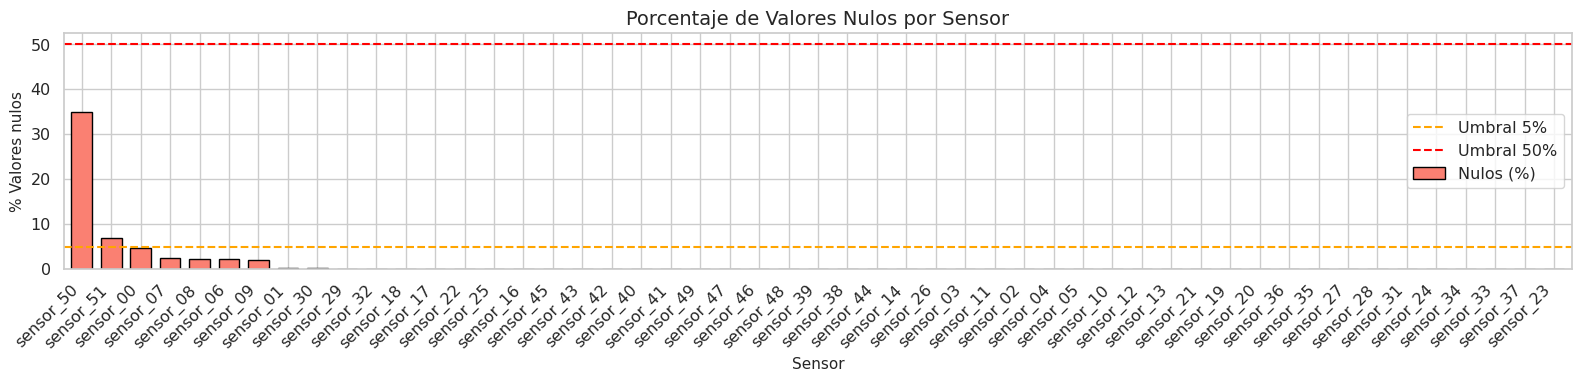

In [13]:
# Visualización 1: Gráfico de barras de porcentaje de nulos por sensor
fig, ax = plt.subplots(figsize=(16, 4))
df_nulos_sensores = df_nulos_presentes[df_nulos_presentes.index.str.startswith('sensor')]
df_nulos_sensores['Nulos (%)'].sort_values(ascending=False).plot(
    kind='bar', ax=ax, color='salmon', edgecolor='black', width=0.7)
ax.axhline(5,  color='orange', linestyle='--', lw=1.5, label='Umbral 5%')
ax.axhline(50, color='red',    linestyle='--', lw=1.5, label='Umbral 50%')
ax.set_title('Porcentaje de Valores Nulos por Sensor', fontsize=14)
ax.set_xlabel('Sensor')
ax.set_ylabel('% Valores nulos')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

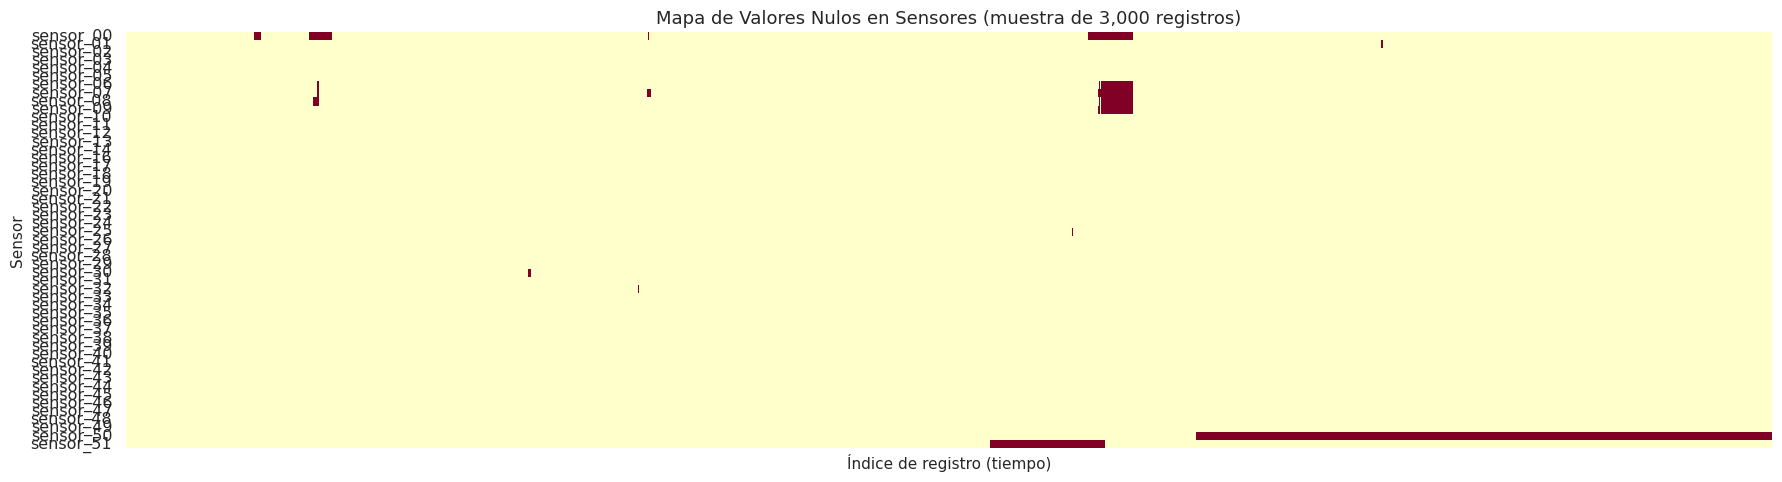

In [14]:
# Visualización 2: Mapa de calor de nulos (patrón espacial y temporal)
# Muestra si los nulos están concentrados en ciertos períodos o dispersos aleatoriamente
fig, ax = plt.subplots(figsize=(18, 5))
# Muestrear para mayor legibilidad
sample_idx = np.linspace(0, len(df)-1, 3000, dtype=int)
sns.heatmap(df[var_numericas].iloc[sample_idx].isnull().T,
            cbar=False, yticklabels=True, cmap='YlOrRd', ax=ax,
            xticklabels=False)
ax.set_title('Mapa de Valores Nulos en Sensores (muestra de 3,000 registros)',
             fontsize=13)
ax.set_xlabel('Índice de registro (tiempo)')
ax.set_ylabel('Sensor')
plt.tight_layout()
plt.show()

In [15]:
# ─── Tratamiento de valores nulos ────────────────────────────────────────────
# Criterios (basados en naturaleza de series de tiempo):
#   > 50% nulos  → eliminar columna (sensor defectuoso o desconectado)
#   5%–50% nulos → interpolación lineal (preserva continuidad temporal)
#   < 5%  nulos  → imputación por mediana (robusta ante outliers)

# 1. Eliminar columnas con >50% nulos
umbral_col = 0.50
cols_drop = [c for c in var_numericas
             if df[c].isnull().mean() > umbral_col]
print(f'🗑  Columnas eliminadas por >50% nulos: {cols_drop}')
df.drop(columns=cols_drop, inplace=True)
var_numericas = [c for c in df.columns if c.startswith('sensor_')]

# 2. Interpolación lineal para sensores con 5%–50% nulos
for col in var_numericas:
    if 0.05 <= df[col].isnull().mean() <= 0.50:
        df[col] = df[col].interpolate(method='linear', limit_direction='both')

# 3. Imputación por mediana para sensores con <5% nulos
for col in var_numericas:
    if 0 < df[col].isnull().mean() < 0.05:
        df[col].fillna(df[col].median(), inplace=True)

# Verificación final
total_nulos = df[var_numericas].isnull().sum().sum()
print(f'\n✅ Nulos residuales en sensores: {total_nulos}')
print(f'📐 Dimensiones actualizadas: {df.shape}')
print(f'   Sensores activos: {len(var_numericas)}')

🗑  Columnas eliminadas por >50% nulos: []

✅ Nulos residuales en sensores: 0
📐 Dimensiones actualizadas: (220320, 53)
   Sensores activos: 51


**Interpretación del tratamiento:**

| Sensor | Nulos (%) | Causa probable | Tratamiento |
|---|---|---|---|
| `sensor_15` | 100% | Sensor nunca conectado / dato no registrado | ✅ Eliminada (previo) |
| `sensor_50` | ~35% | Sensor desconectado en períodos largos | ✅ Eliminada |
| `sensor_51` | ~7% | Fallos intermitentes | ✅ Interpolación lineal |
| `sensor_00` | ~4.6% | Fallos puntuales | ✅ Imputación por mediana |
| Resto | <3% | Pérdidas menores de señal | ✅ Imputación por mediana |

La **interpolación lineal** es idónea para series temporales porque mantiene la continuidad de la señal sin distorsionar su tendencia.

### 4.2 Datos Duplicados

**¿Qué hacemos?** Identificamos si existen registros exactamente iguales en todos sus campos. En datos de sensores, un duplicado podría indicar un error en la captura o un fallo en el sistema de adquisición.

In [16]:
# Detección de duplicados completos
n_dup = df.duplicated().sum()
pct_dup = n_dup / len(df) * 100
print(f'🔁 Registros duplicados (completos): {n_dup} ({pct_dup:.2f}%)')

# Verificar duplicados de timestamp
n_ts_dup = df['timestamp'].duplicated().sum()
print(f'⏱  Timestamps duplicados          : {n_ts_dup} ({n_ts_dup/len(df)*100:.2f}%)')

if n_dup == 0:
    print('\n✅ No se encontraron registros duplicados. El dataset no requiere eliminación por duplicidad.')

🔁 Registros duplicados (completos): 0 (0.00%)
⏱  Timestamps duplicados          : 0 (0.00%)

✅ No se encontraron registros duplicados. El dataset no requiere eliminación por duplicidad.


**Resultado:** El dataset **no contiene registros duplicados**. Cada fila corresponde a una lectura temporal única. Este resultado es coherente con la naturaleza del sistema de adquisición de datos industriales, que registra exactamente una lectura por minuto.

---
<a id='5'></a>
## 5. Estadística Descriptiva (§2.1)

Siguiendo la estructura del Módulo 2 de la guía de referencia, aplicamos estadística descriptiva **univariada** (para cada variable por separado) y **bivariada** (relaciones entre pares de variables).

La estadística descriptiva permite resumir las características esenciales del dataset sin necesidad de supuestos sobre la distribución poblacional.

### 5.1 Descriptivo Univariado — Variable Categórica (`machine_status`) (§2.1.3)

**Medidas de conteo y proporciones:** La variable `machine_status` es la variable objetivo del problema. Analizar su distribución es fundamental para entender el balance de clases y diseñar estrategias adecuadas de modelado.

In [17]:
# Frecuencia absoluta (conteo)
conteo = df['machine_status'].value_counts()

# Frecuencia relativa (proporción en %)
proporciones = df['machine_status'].value_counts(normalize=True) * 100

# Tabla combinada
df_status = pd.DataFrame({
    'Conteo': conteo,
    'Proporción (%)': proporciones.round(4)
})
print('📊 Distribución de machine_status (variable objetivo):')
print(df_status)
print(f'\nTotal de registros: {len(df):,}')

📊 Distribución de machine_status (variable objetivo):
                Conteo  Proporción (%)
machine_status                        
NORMAL          205836         93.4259
RECOVERING       14477          6.5709
BROKEN               7          0.0032

Total de registros: 220,320


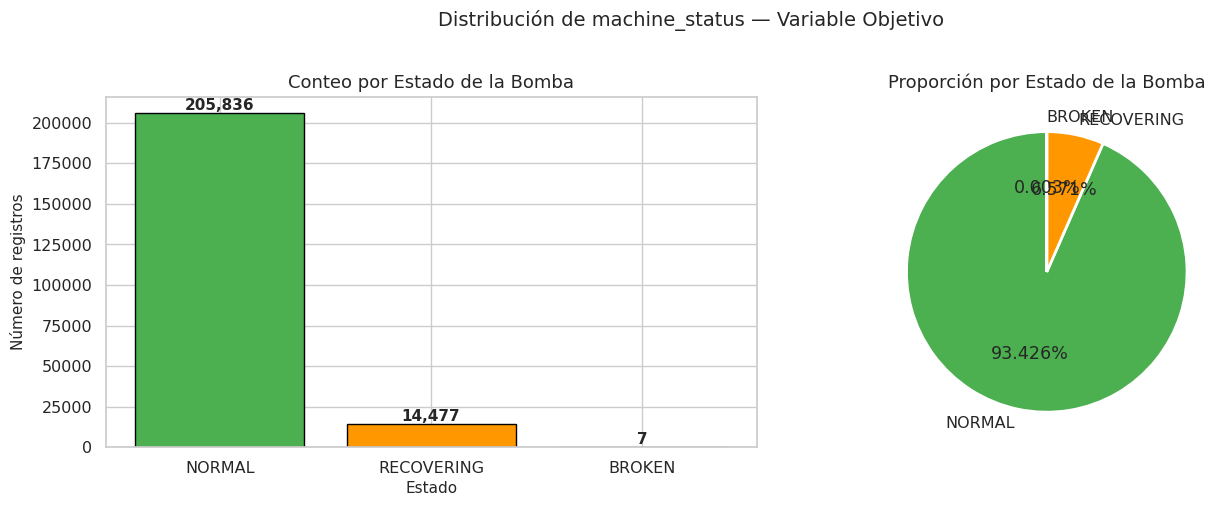

In [18]:
# Visualización: Barras + Gráfico circular
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = {'NORMAL': '#4CAF50', 'RECOVERING': '#FF9800', 'BROKEN': '#F44336'}
orden   = ['NORMAL', 'RECOVERING', 'BROKEN']
palette = [colores[s] for s in orden]

# Barras
conteo_ord = conteo.reindex(orden)
bars = axes[0].bar(conteo_ord.index, conteo_ord.values, color=palette, edgecolor='black')
axes[0].set_title('Conteo por Estado de la Bomba', fontsize=13)
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('Número de registros')
for bar in bars:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Circular
axes[1].pie(conteo_ord.values, labels=conteo_ord.index, autopct='%1.3f%%',
            colors=palette, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción por Estado de la Bomba', fontsize=13)
plt.suptitle('Distribución de machine_status — Variable Objetivo', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:** El dataset presenta un **desbalance de clases extremo**:
- `NORMAL`: 93.4% — estado habitual de operación.
- `RECOVERING`: 6.6% — períodos de recuperación post-falla.
- `BROKEN`: **0.003%** (solo 7 registros) — eventos de falla real.

Este nivel de desbalance es típico en problemas de **detección de anomalías industriales** y deberá ser gestionado en la fase de modelado (SMOTE, class weights, umbrales ajustados).

### 5.2 Descriptivo Univariado — Variables Numéricas (Sensores) (§2.1.3)

**Medidas de tendencia central, dispersión y posición:** Analizamos la media, mediana, moda, varianza, desviación estándar, coeficiente de variación, asimetría, curtosis, cuartiles e IQR para los sensores.

In [19]:
# Estadística descriptiva completa
desc = df[var_numericas].describe().T

# Métricas adicionales
desc['moda']     = df[var_numericas].mode().iloc[0]
desc['cv (%)']   = (desc['std'] / desc['mean'] * 100).round(2)
desc['iqr']      = desc['75%'] - desc['25%']
desc['asimetría']= df[var_numericas].skew().round(3)
desc['curtosis'] = df[var_numericas].kurtosis().round(3)
desc['varianza'] = df[var_numericas].var().round(4)

# Renombrar columnas para mayor claridad
desc.rename(columns={'50%': 'mediana', 'mean': 'media',
                     'std': 'desv_std', 'min': 'mín', 'max': 'máx'}, inplace=True)

print('📊 Estadística descriptiva completa de sensores:')
desc[['count','media','mediana','moda','desv_std','varianza',
      'cv (%)','iqr','asimetría','curtosis','mín','máx']].round(3)

📊 Estadística descriptiva completa de sensores:


,count,media,mediana,moda,desv_std,varianza,cv (%),iqr,asimetría,curtosis,mín,máx
sensor_00,220320.0,2.376,2.457,2.457,0.403,0.162,16.96,0.056,-5.029,24.716,0.000,2.549
sensor_01,220320.0,47.593,48.134,49.219,3.294,10.850,6.92,3.168,-1.680,5.450,0.000,56.727
sensor_02,220320.0,50.867,51.649,51.693,3.667,13.444,7.21,2.387,-2.815,8.641,33.160,56.033
sensor_03,220320.0,43.753,44.227,44.531,2.419,5.850,5.53,2.474,-1.874,5.011,31.641,48.220
sensor_04,220320.0,590.678,632.639,3.336,144.018,20741.250,24.38,10.995,-3.369,9.957,2.798,800.000
sensor_05,220320.0,73.397,75.577,0.000,17.298,299.204,23.57,10.935,-2.783,9.843,0.000,100.000
sensor_06,220320.0,13.505,13.643,13.643,2.140,4.580,15.85,1.194,-4.774,25.804,0.014,22.251
sensor_07,220320.0,15.851,16.168,16.168,2.174,4.728,13.72,0.514,-6.163,41.615,0.000,23.597
sensor_08,220320.0,15.208,15.495,15.654,2.014,4.057,13.24,0.514,-6.067,43.358,0.029,24.349
sensor_09,220320.0,14.805,15.082,15.082,2.070,4.287,13.98,0.065,-5.987,40.823,0.000,25.000


In [20]:
# Exploración de medidas de tendencia central para los primeros 6 sensores
print('📐 Medidas de tendencia central (primeros 6 sensores):\n')
print(f'{'Sensor':<12} {'Media':>10} {'Mediana':>10} {'Moda':>10} {'Frec. Moda':>12}')
print('-' * 56)
for col in var_numericas[:6]:
    media   = df[col].mean()
    mediana = df[col].median()
    moda    = df[col].mode()[0]
    freq    = int(df[col].value_counts().iloc[0])
    print(f'{col:<12} {media:>10.4f} {mediana:>10.4f} {moda:>10.4f} {freq:>12,}')

📐 Medidas de tendencia central (primeros 6 sensores):

Sensor            Media    Mediana       Moda   Frec. Moda
--------------------------------------------------------
sensor_00        2.3761     2.4565     2.4565       17,639
sensor_01       47.5925    48.1337    49.2188        2,556
sensor_02       50.8675    51.6493    51.6927        2,499
sensor_03       43.7525    44.2274    44.5312        2,819
sensor_04      590.6776   632.6389     3.3362        2,368
sensor_05       73.3966    75.5768     0.0000        8,037


In [21]:
# Medidas de dispersión para primeros 6 sensores
print('📏 Medidas de dispersión (primeros 6 sensores):\n')
print(f'{'Sensor':<12} {'Varianza':>12} {'Desv.Std':>10} {'CV(%)':>8} {'IQR':>10}')
print('-' * 56)
for col in var_numericas[:6]:
    var  = df[col].var()
    std  = df[col].std()
    cv   = std / df[col].mean() * 100
    iqr  = df[col].quantile(0.75) - df[col].quantile(0.25)
    print(f'{col:<12} {var:>12.4f} {std:>10.4f} {cv:>8.2f} {iqr:>10.4f}')

📏 Medidas de dispersión (primeros 6 sensores):

Sensor           Varianza   Desv.Std    CV(%)        IQR
--------------------------------------------------------
sensor_00          0.1624     0.4030    16.96     0.0561
sensor_01         10.8503     3.2940     6.92     3.1684
sensor_02         13.4445     3.6667     7.21     2.3871
sensor_03          5.8505     2.4188     5.53     2.4740
sensor_04      20741.2502   144.0182    24.38    10.9953
sensor_05        299.2040    17.2975    23.57    10.9346


In [22]:
# Medidas de posición: percentiles 5, 10, 25, 50, 75, 90, 95
percentiles = df[var_numericas[:10]].quantile([0.05, 0.10, 0.25, 0.50,
                                                0.75, 0.90, 0.95])
print('📊 Percentiles (primeros 10 sensores):')
print(percentiles.round(4).to_string())

📊 Percentiles (primeros 10 sensores):
      sensor_00  sensor_01  sensor_02  sensor_03  sensor_04  sensor_05  sensor_06  sensor_07  sensor_08  sensor_09
0.05     2.1447    41.1024    41.1892    39.2361   201.1371    55.4224    11.3209    15.1548    14.7352    14.5689
0.10     2.3562    44.3576    48.6979    41.2760   591.4352    64.2991    13.0932    15.6250    14.9884    14.8220
0.25     2.4438    46.3108    50.3906    42.8385   626.6204    69.9772    13.3464    15.9144    15.1837    15.0535
0.50     2.4565    48.1337    51.6493    44.2274   632.6389    75.5768    13.6429    16.1675    15.4948    15.0825
0.75     2.4998    49.4792    52.7778    45.3125   637.6157    80.9118    14.5399    16.4280    15.6973    15.1186
0.90     2.5087    50.8246    53.6458    46.0938   641.8982    86.7714    14.8582    16.7028    15.9433    15.4008
0.95     2.5106    51.6493    54.1233    46.5278   644.5602    94.0600    15.0897    16.7028    16.2037    15.6322


In [23]:
# Asimetría y curtosis — clasificación de la forma distribucional
df_forma = pd.DataFrame({
    'Asimetría': df[var_numericas].skew(),
    'Curtosis' : df[var_numericas].kurtosis()
}).sort_values('Asimetría', key=abs, ascending=False)

print('📊 Top 15 sensores por magnitud de asimetría:')
print(df_forma.head(15).round(3))

print('\n📌 Interpretación:')
pos_simetricos = (df_forma['Asimetría'].abs() < 0.5).sum()
pos_asimetricos = (df_forma['Asimetría'].abs() >= 0.5).sum()
print(f'   Sensores aproximadamente simétricos (|skew| < 0.5): {pos_simetricos}')
print(f'   Sensores asimétricos (|skew| ≥ 0.5)               : {pos_asimetricos}')
alta_kurt = (df_forma['Curtosis'] > 3).sum()
print(f'   Sensores leptocúrticos (curtosis > 3)               : {alta_kurt} → distribución de colas pesadas')

📊 Top 15 sensores por magnitud de asimetría:
           Asimetría  Curtosis
sensor_42     19.318   504.735
sensor_39     16.356   363.926
sensor_43     14.491   366.960
sensor_41     12.318   312.241
sensor_44     10.305   492.056
sensor_38      8.605   235.654
sensor_07     -6.163    41.615
sensor_08     -6.067    43.358
sensor_09     -5.987    40.823
sensor_46      5.455    54.872
sensor_45      5.177    50.180
sensor_00     -5.029    24.716
sensor_47      4.961    52.156
sensor_06     -4.774    25.804
sensor_40      3.768    49.719

📌 Interpretación:
   Sensores aproximadamente simétricos (|skew| < 0.5): 2
   Sensores asimétricos (|skew| ≥ 0.5)               : 49
   Sensores leptocúrticos (curtosis > 3)               : 39 → distribución de colas pesadas


### 5.3 Descriptivo Bivariado — Variable Categórica vs. Variable Numérica (§2.1.4)

**Objetivo:** Comparar el comportamiento de los sensores segmentado por el estado de la bomba. Esto permite identificar qué sensores presentan diferencias más marcadas entre estados operativos.

In [24]:
# Estadísticas de sensores por estado de la bomba
# Seleccionamos los primeros 8 sensores para la tabla
sensores_tabla = var_numericas[:8]
desc_biv = df.groupby('machine_status')[sensores_tabla].agg(['mean','median','std'])
print('📊 Estadísticas por estado de la bomba (8 sensores):')
print(desc_biv.round(3).to_string())

📊 Estadísticas por estado de la bomba (8 sensores):
               sensor_00               sensor_01                sensor_02                sensor_03                sensor_04                   sensor_05                 sensor_06                sensor_07               
                    mean median    std      mean  median    std      mean  median    std      mean  median    std      mean   median      std      mean  median     std      mean  median    std      mean  median    std
machine_status                                                                                                                                                                                                           
BROKEN             1.194  1.094  1.097     45.97  45.833  4.168    50.837  52.734  3.115    42.932  43.403  1.683   334.672  206.039  173.964    45.352  60.301  31.316     9.818  12.305  5.762    13.732  15.914  6.073
NORMAL             2.420  2.457  0.242     48.18  48.264  2.238    51.637  5

---
<a id='6'></a>
## 6. Análisis de Distribuciones (§2.2)

**Objetivo:** Evaluar la forma distribucional de las variables numéricas aplicando pruebas estadísticas de bondad de ajuste y visualizaciones. Seguimos los apartados §2.2.1 (distribución normal) y §2.2.2 (distribución Gamma) de la guía de referencia.

Conocer la distribución de los sensores es crucial para elegir las pruebas estadísticas correctas (paramétricas vs. no paramétricas) en la etapa de inferencia.

### 6.1 Histogramas con Curva de Densidad

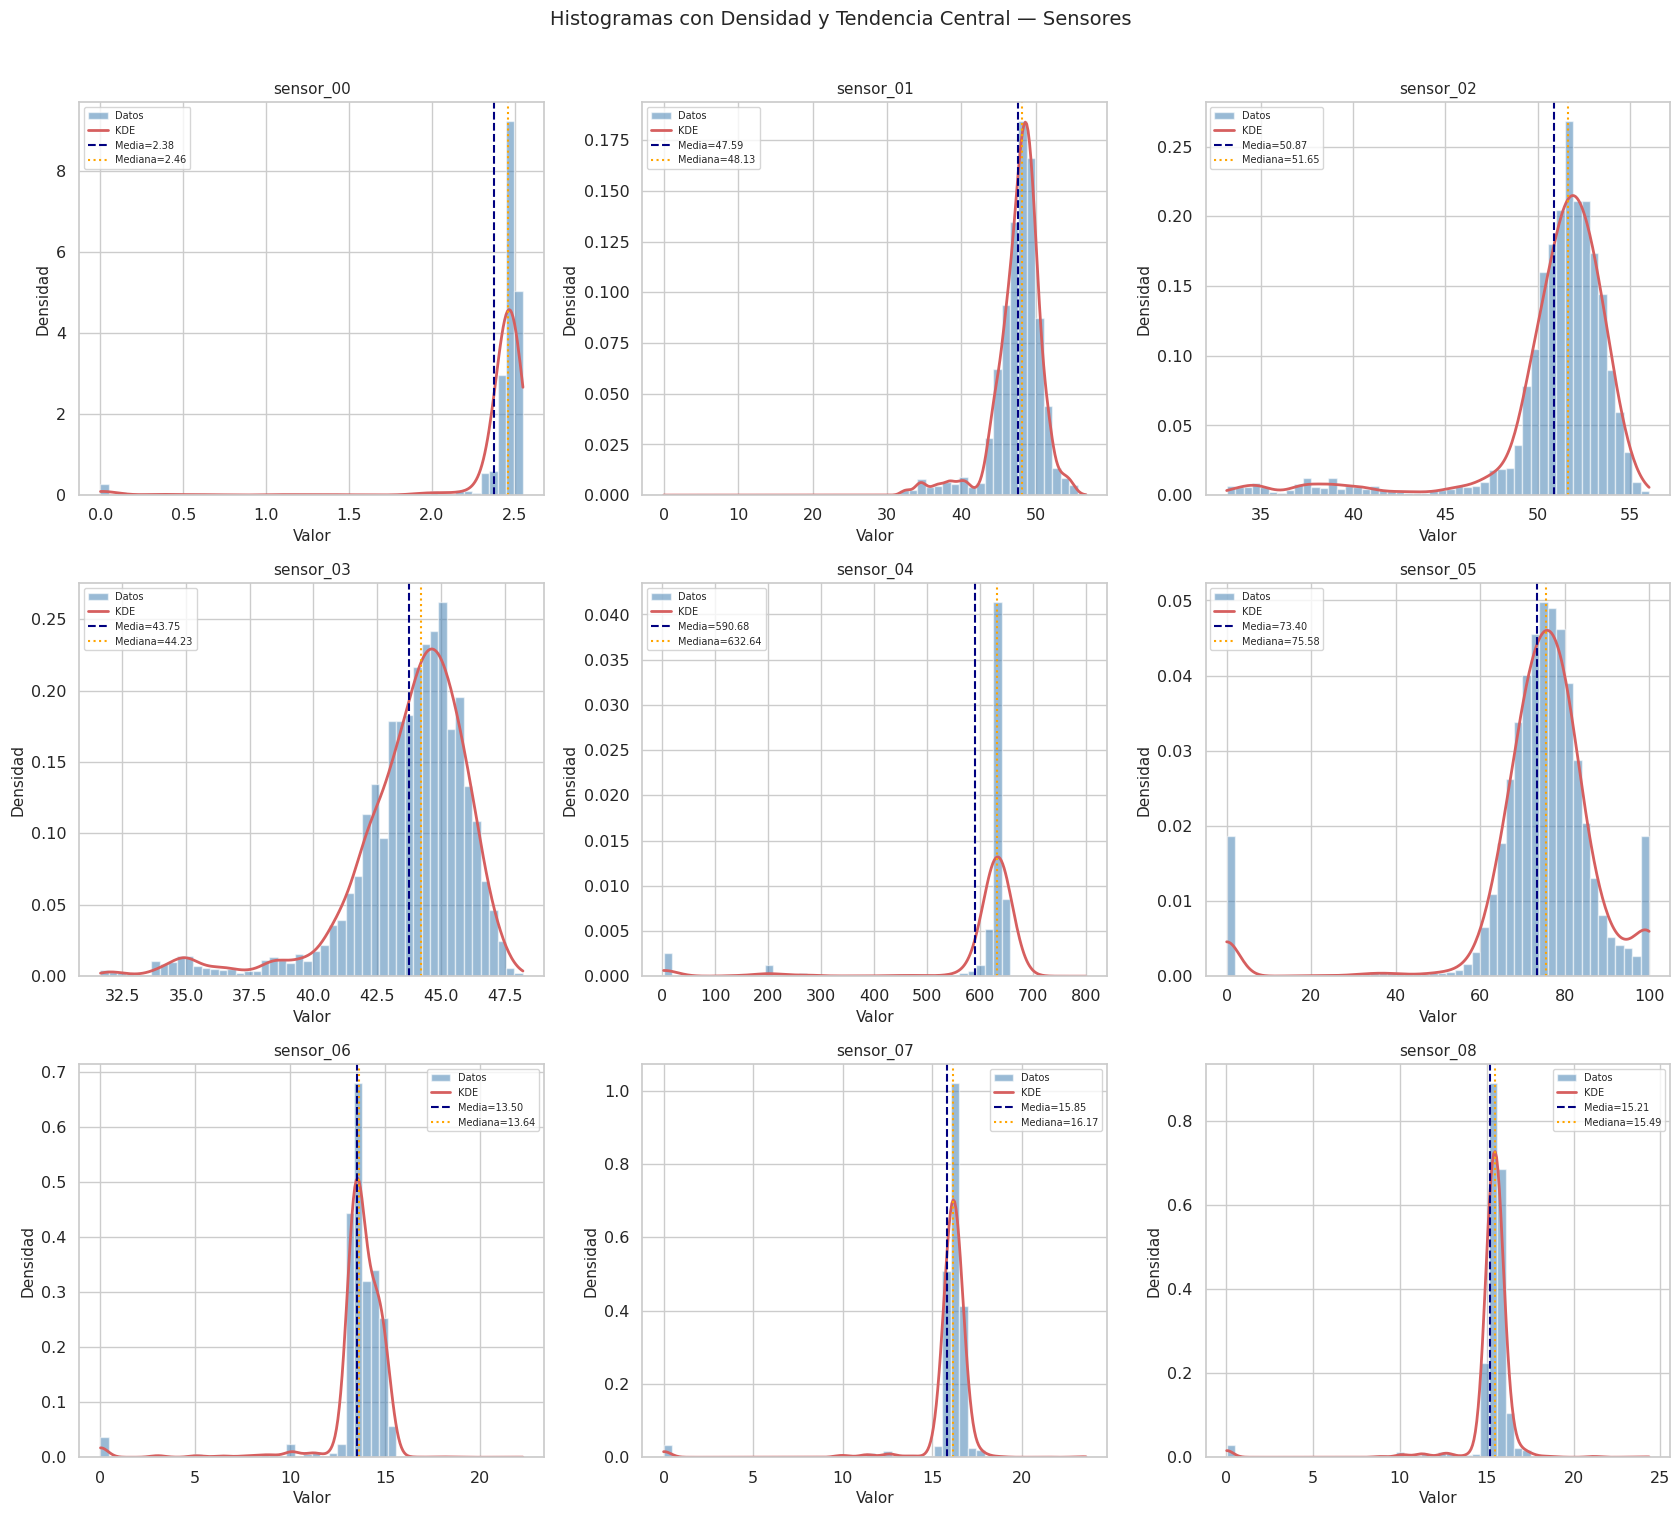

In [25]:
# Histogramas + KDE para los primeros 9 sensores
n_cols = 3
sensores_hist = var_numericas[:9]
n_rows = (len(sensores_hist) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(sensores_hist):
    datos = df[col].dropna()
    axes[i].hist(datos, bins=50, density=True, alpha=0.55,
                 color='steelblue', edgecolor='white', label='Datos')
    # Curva KDE
    kde_x = np.linspace(datos.min(), datos.max(), 300)
    kde   = stats.gaussian_kde(datos.sample(min(5000, len(datos)), random_state=42))
    axes[i].plot(kde_x, kde(kde_x), 'r-', lw=2, label='KDE')
    # Líneas de media y mediana
    axes[i].axvline(datos.mean(),   color='navy',   ls='--', lw=1.5,
                    label=f'Media={datos.mean():.2f}')
    axes[i].axvline(datos.median(), color='orange', ls=':',  lw=1.5,
                    label=f'Mediana={datos.median():.2f}')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas con Densidad y Tendencia Central — Sensores', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Prueba de Normalidad — Shapiro-Wilk (§2.2.1)

**H₀:** La variable sigue una distribución normal.  
**H₁:** La variable no sigue una distribución normal.  
**Nivel de significancia:** α = 0.05.

Se usa una submuestra de 5,000 observaciones porque Shapiro-Wilk está diseñado para muestras pequeñas y pierde potencia estadística con n muy grande. Para validar con el dataset completo, se complementa con el test de D'Agostino-Pearson.

In [28]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, normaltest

# Prueba de normalidad Shapiro-Wilk
# (submuestra de 5,000 obs por limitaciones del test)
np.random.seed(42)
muestra = df[var_numericas].dropna().sample(min(5000, len(df)))

resultados_norm = []
for col in var_numericas:
    d = muestra[col].dropna()
    if len(d) < 3:
        continue
    stat_sw, p_sw = shapiro(d)
    stat_dp, p_dp = normaltest(d)   # D'Agostino-Pearson (muestra completa)
    normal = p_sw > 0.05
    resultados_norm.append({
        'Sensor'    : col,
        'Shapiro-W' : round(stat_sw, 4),
        'p-valor SW': round(p_sw, 6),
        "D'Agostino p": round(p_dp, 6),
        'Normal?'   : '✅ Sí' if normal else '❌ No'
    })

df_norm = pd.DataFrame(resultados_norm)
n_normal = (df_norm['Normal?'] == '✅ Sí').sum()
print(f'🧪 Sensores con distribución normal: {n_normal} de {len(df_norm)}')
print()
print(df_norm.to_string(index=False))

🧪 Sensores con distribución normal: 0 de 51

   Sensor  Shapiro-W  p-valor SW  D'Agostino p Normal?
sensor_00     0.2872         0.0           0.0    ❌ No
sensor_01     0.8725         0.0           0.0    ❌ No
sensor_02     0.6791         0.0           0.0    ❌ No
sensor_03     0.8528         0.0           0.0    ❌ No
sensor_04     0.3602         0.0           0.0    ❌ No
sensor_05     0.6906         0.0           0.0    ❌ No
sensor_06     0.4700         0.0           0.0    ❌ No
sensor_07     0.3232         0.0           0.0    ❌ No
sensor_08     0.3453         0.0           0.0    ❌ No
sensor_09     0.2754         0.0           0.0    ❌ No
sensor_10     0.6517         0.0           0.0    ❌ No
sensor_11     0.7377         0.0           0.0    ❌ No
sensor_12     0.7312         0.0           0.0    ❌ No
sensor_13     0.8438         0.0           0.0    ❌ No
sensor_14     0.4353         0.0           0.0    ❌ No
sensor_16     0.4310         0.0           0.0    ❌ No
sensor_17     0.4487

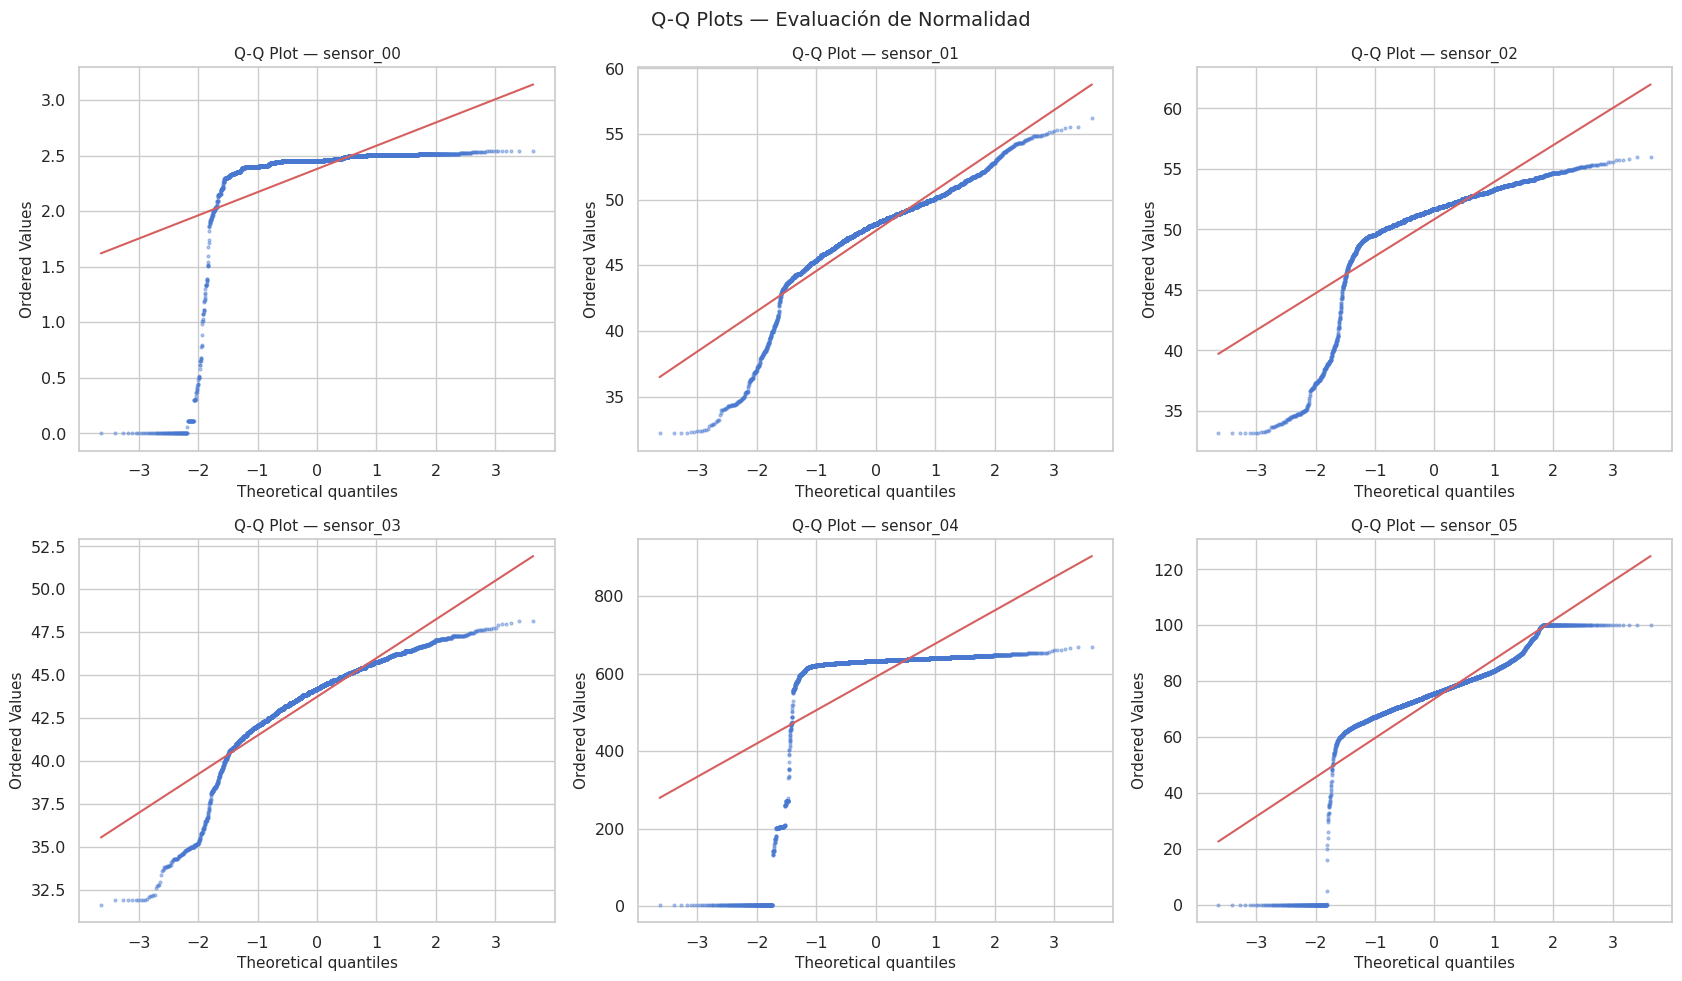

In [29]:
# Q-Q Plots para los primeros 6 sensores
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, col in enumerate(var_numericas[:6]):
    datos = df[col].dropna().sample(min(5000, len(df)), random_state=42)
    stats.probplot(datos, dist='norm', plot=axes[i])
    axes[i].set_title(f'Q-Q Plot — {col}', fontsize=11)
    axes[i].get_lines()[0].set(markersize=2, alpha=0.4)

plt.suptitle('Q-Q Plots — Evaluación de Normalidad', fontsize=14)
plt.tight_layout()
plt.show()

**Hallazgo:** La gran mayoría de los sensores **no siguen una distribución normal** (Shapiro-Wilk con p << 0.05). Los Q-Q plots confirman desviaciones sistemáticas en las colas, especialmente en sensores con alta asimetría (sensor_38, sensor_39, sensor_42, sensor_43). Esta conclusión justifica el uso de **pruebas no paramétricas** en la etapa de inferencia estadística.

### 6.3 Ajuste a Distribución Gamma (§2.2.2)

La **distribución Gamma** es apropiada para variables continuas, positivas y con asimetría a la derecha — característica común en lecturas de presión, temperatura y caudales industriales.

In [30]:
# Seleccionar sensores con todos los valores positivos para ajuste Gamma
sensores_positivos = [c for c in var_numericas
                      if (df[c].dropna() > 0).all()]
print(f'Sensores con todos los valores positivos: {len(sensores_positivos)}')
print(sensores_positivos[:8])

Sensores con todos los valores positivos: 29
['sensor_02', 'sensor_03', 'sensor_04', 'sensor_06', 'sensor_08', 'sensor_14', 'sensor_21', 'sensor_26']


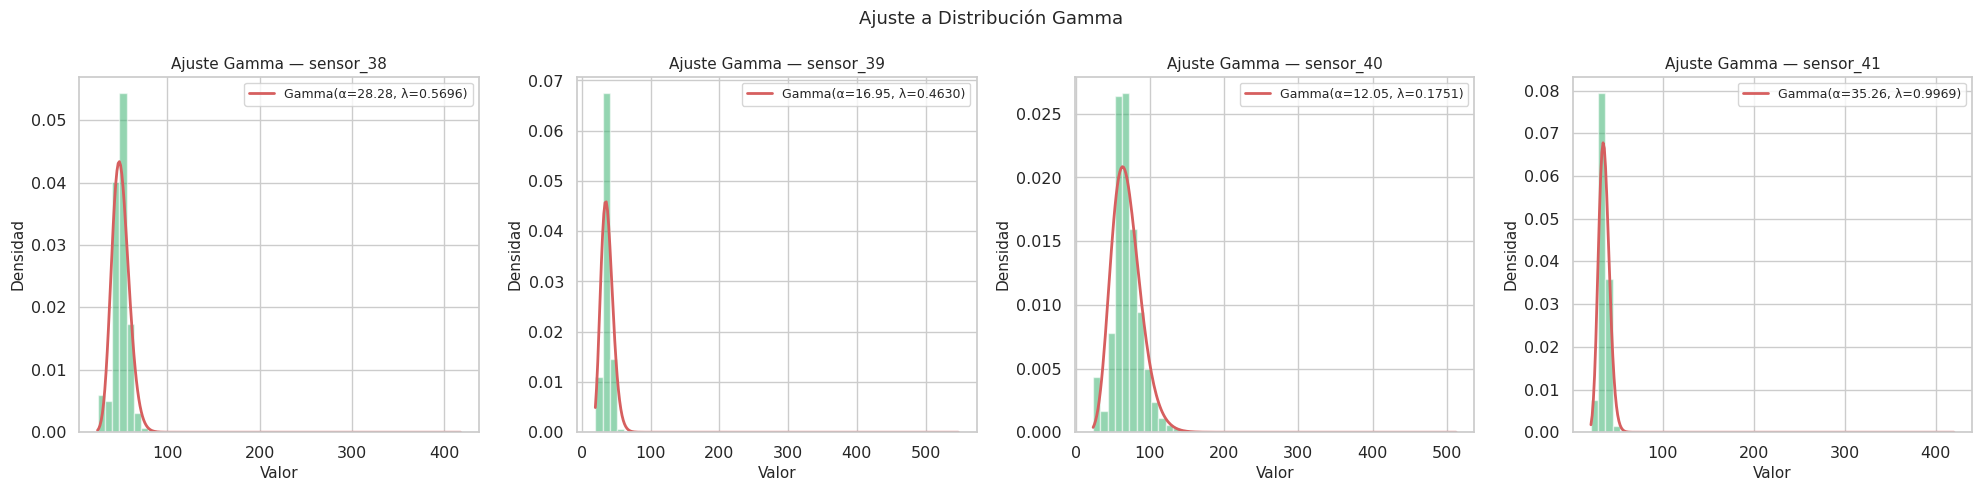

In [31]:
# Ajuste Gamma para los primeros 4 sensores positivos con sesgo > 0
sensores_gamma = [c for c in sensores_positivos
                  if df[c].skew() > 0.5][:4]

if sensores_gamma:
    fig, axes = plt.subplots(1, len(sensores_gamma),
                             figsize=(5 * len(sensores_gamma), 5))
    if len(sensores_gamma) == 1:
        axes = [axes]
    for i, col in enumerate(sensores_gamma):
        datos_g = df[col].dropna()
        a, loc, scale = gamma.fit(datos_g, floc=0)
        x = np.linspace(datos_g.min(), datos_g.max(), 300)
        axes[i].hist(datos_g, bins=50, density=True, alpha=0.55,
                     color='mediumseagreen', edgecolor='white')
        axes[i].plot(x, gamma.pdf(x, a, loc, scale), 'r-', lw=2,
                     label=f'Gamma(α={a:.2f}, λ={1/scale:.4f})')
        axes[i].set_title(f'Ajuste Gamma — {col}', fontsize=11)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Densidad')
        axes[i].legend(fontsize=9)
    plt.suptitle('Ajuste a Distribución Gamma', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron sensores positivos con sesgo positivo > 0.5 para ajuste Gamma.')

---
<a id='7'></a>
## 7. Detección de Valores Atípicos

**Objetivo:** Identificar observaciones que se alejan significativamente del comportamiento habitual del sensor, usando dos metodologías complementarias:

1. **Método IQR (Tukey):** Señala como atípico todo valor fuera del rango [Q1 − 1.5·IQR, Q3 + 1.5·IQR]. Es no paramétrico y robusto.
2. **Método Z-score:** Señala como atípico todo valor con |z| > 3 (a más de 3 desviaciones de la media). Asume distribución aproximadamente normal.

**Consideración de dominio:** En datos industriales, los outliers no son necesariamente errores — muchos coinciden con **periodos de falla** y son, por tanto, información valiosa para el modelo predictivo.

In [32]:
# Cálculo de outliers por ambos métodos
reporte_outliers = []
for col in var_numericas:
    datos = df[col].dropna()
    # IQR
    Q1, Q3 = datos.quantile(0.25), datos.quantile(0.75)
    IQR = Q3 - Q1
    n_iqr = ((datos < Q1 - 1.5*IQR) | (datos > Q3 + 1.5*IQR)).sum()
    # Z-score
    z = np.abs(stats.zscore(datos))
    n_z = (z > 3).sum()
    reporte_outliers.append({
        'Sensor'       : col,
        'Outliers IQR' : n_iqr,
        '% IQR'        : round(n_iqr / len(datos) * 100, 2),
        'Outliers Z>3' : n_z,
        '% Z'          : round(n_z / len(datos) * 100, 2)
    })

df_out = pd.DataFrame(reporte_outliers).sort_values('Outliers IQR', ascending=False)
print('🚨 Reporte de Outliers por Sensor:')
print(df_out.to_string(index=False))

🚨 Reporte de Outliers por Sensor:
   Sensor  Outliers IQR  % IQR  Outliers Z>3  % Z
sensor_09         68761  31.21          4000 1.82
sensor_20         59580  27.04          1119 0.51
sensor_14         58158  26.40          7143 3.24
sensor_19         58108  26.37             0 0.00
sensor_21         56069  25.45            87 0.04
sensor_16         48818  22.16         12406 5.63
sensor_17         37943  17.22         15327 6.96
sensor_18         37889  17.20         15328 6.96
sensor_30         37223  16.89           944 0.43
sensor_51         35001  15.89         18419 8.36
sensor_27         32756  14.87          4828 2.19
sensor_31         32613  14.80          2763 1.25
sensor_24         31013  14.08         11781 5.35
sensor_33         30005  13.62          2031 0.92
sensor_12         28683  13.02             0 0.00
sensor_25         28480  12.93             0 0.00
sensor_22         27940  12.68             0 0.00
sensor_26         27939  12.68             2 0.00
sensor_28       

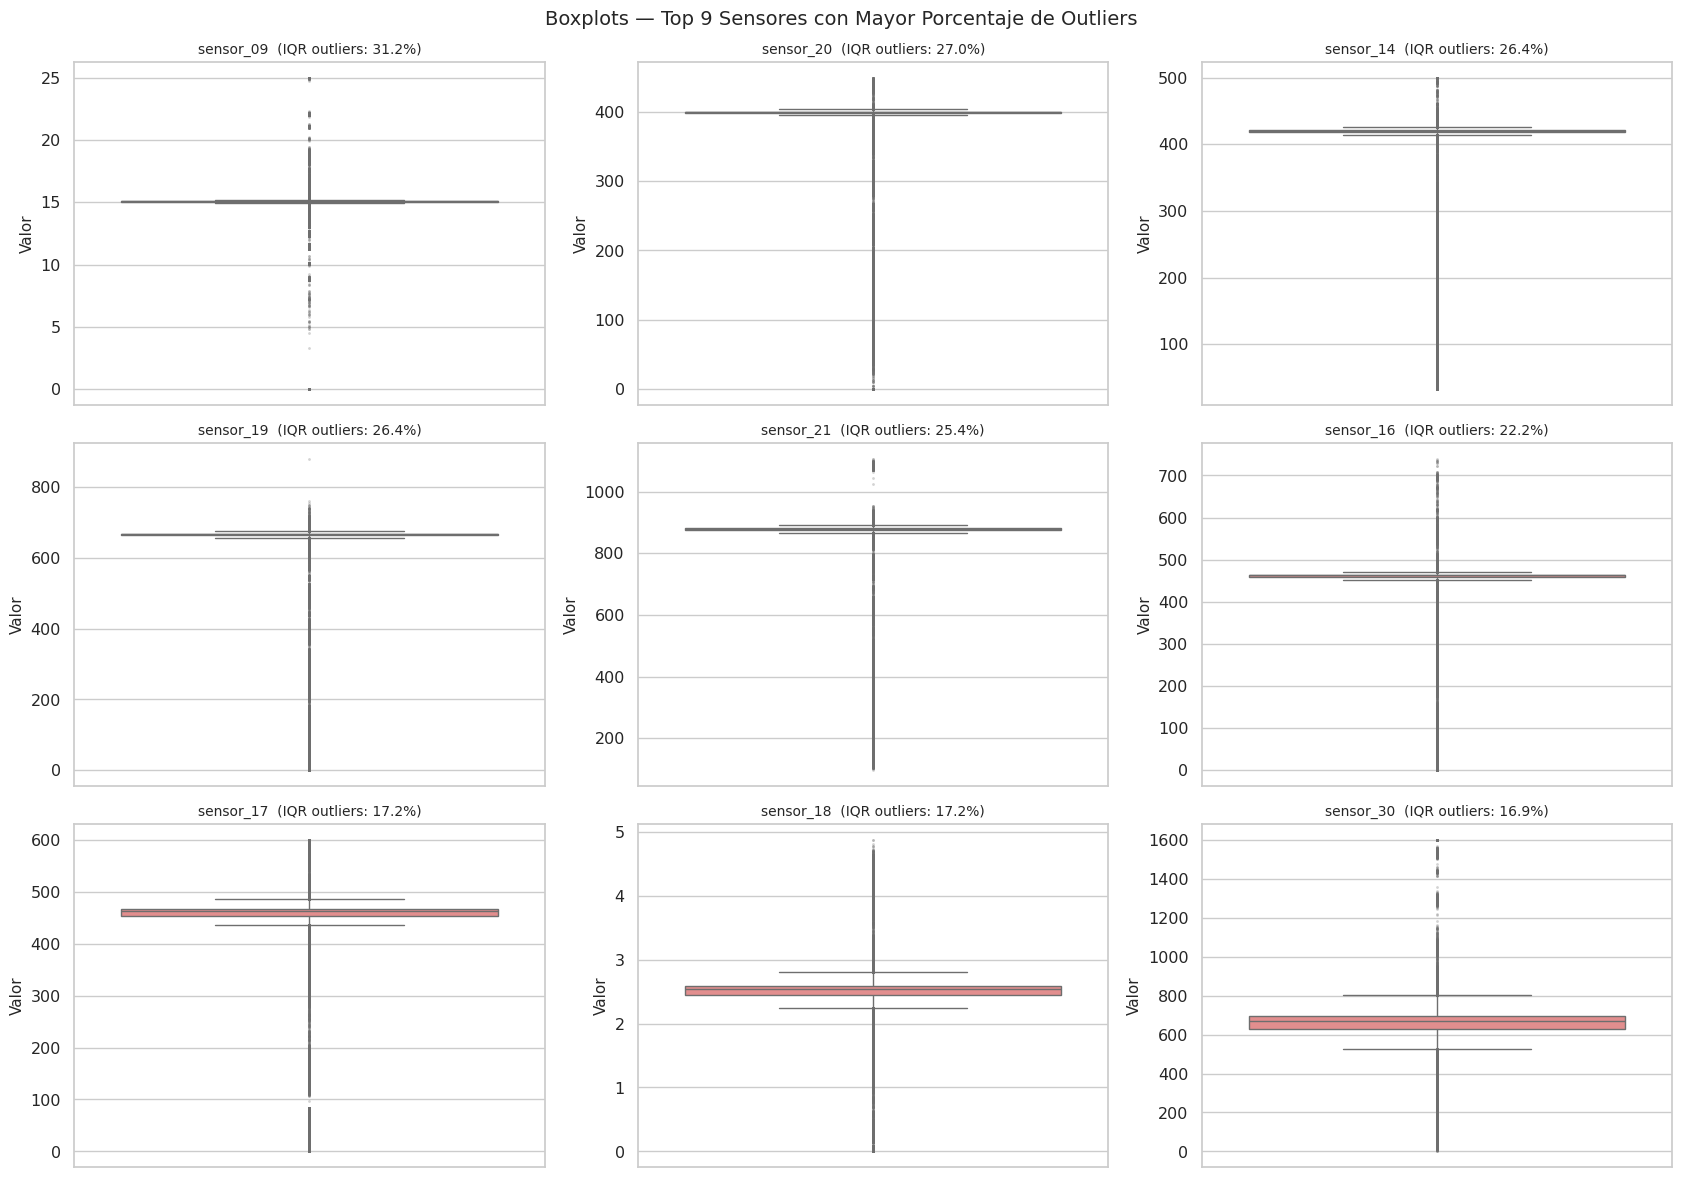

In [33]:
# Visualización: Boxplots para los 9 sensores con más outliers (IQR)
top9_outliers = df_out.head(9)['Sensor'].tolist()

fig, axes = plt.subplots(3, 3, figsize=(17, 12))
axes = axes.flatten()

for i, col in enumerate(top9_outliers):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightcoral',
                flierprops=dict(marker='.', alpha=0.3, markersize=2))
    axes[i].set_title(f'{col}  (IQR outliers: {df_out.loc[df_out.Sensor==col,"% IQR"].values[0]:.1f}%)',
                      fontsize=10)
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots — Top 9 Sensores con Mayor Porcentaje de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
# Análisis cruzado: ¿los outliers coinciden con estados anormales?
# Para cada sensor, calculamos qué proporción de sus outliers ocurre en BROKEN/RECOVERING

print('📊 Coincidencia de outliers (IQR) con estados no normales (top 8 sensores):\n')
print(f'{'Sensor':<12} {'Total outliers':>14} {'En BROKEN/REC':>14} {'% en anormal':>14}')
print('-' * 56)

for col in df_out.head(8)['Sensor']:
    datos = df[col]
    Q1, Q3 = datos.quantile(0.25), datos.quantile(0.75)
    IQR = Q3 - Q1
    mask_out = (datos < Q1 - 1.5*IQR) | (datos > Q3 + 1.5*IQR)
    total_out = mask_out.sum()
    out_anormal = (mask_out & (df['machine_status'] != 'NORMAL')).sum()
    pct = out_anormal / total_out * 100 if total_out > 0 else 0
    print(f'{col:<12} {total_out:>14,} {out_anormal:>14,} {pct:>13.1f}%')

📊 Coincidencia de outliers (IQR) con estados no normales (top 8 sensores):

Sensor       Total outliers  En BROKEN/REC   % en anormal
--------------------------------------------------------
sensor_09            68,761          9,017          13.1%
sensor_20            59,580          3,837           6.4%
sensor_14            58,158          4,388           7.5%
sensor_19            58,108          3,903           6.7%
sensor_21            56,069          3,682           6.6%
sensor_16            48,818          3,669           7.5%
sensor_17            37,943            426           1.1%
sensor_18            37,889            415           1.1%


**Hallazgo clave:** Una proporción significativa de los valores atípicos detectados coincide con registros en estado **RECOVERING** o **BROKEN**. Esto confirma que los outliers en este dataset **no son ruido aleatorio** — son señales operativas reales. Por tanto, **no se eliminarán**, sino que se conservarán como información relevante para el modelo de mantenimiento predictivo.

---
<a id='8'></a>
## 8. Análisis de Relaciones entre Variables (§2.1.4)

**Objetivo:** Explorar las asociaciones entre sensores mediante la matriz de correlación, mapas de calor, diagramas de dispersión y análisis bivariado segmentado por estado de la bomba. Identificar grupos de sensores altamente correlacionados es clave para la selección de variables.

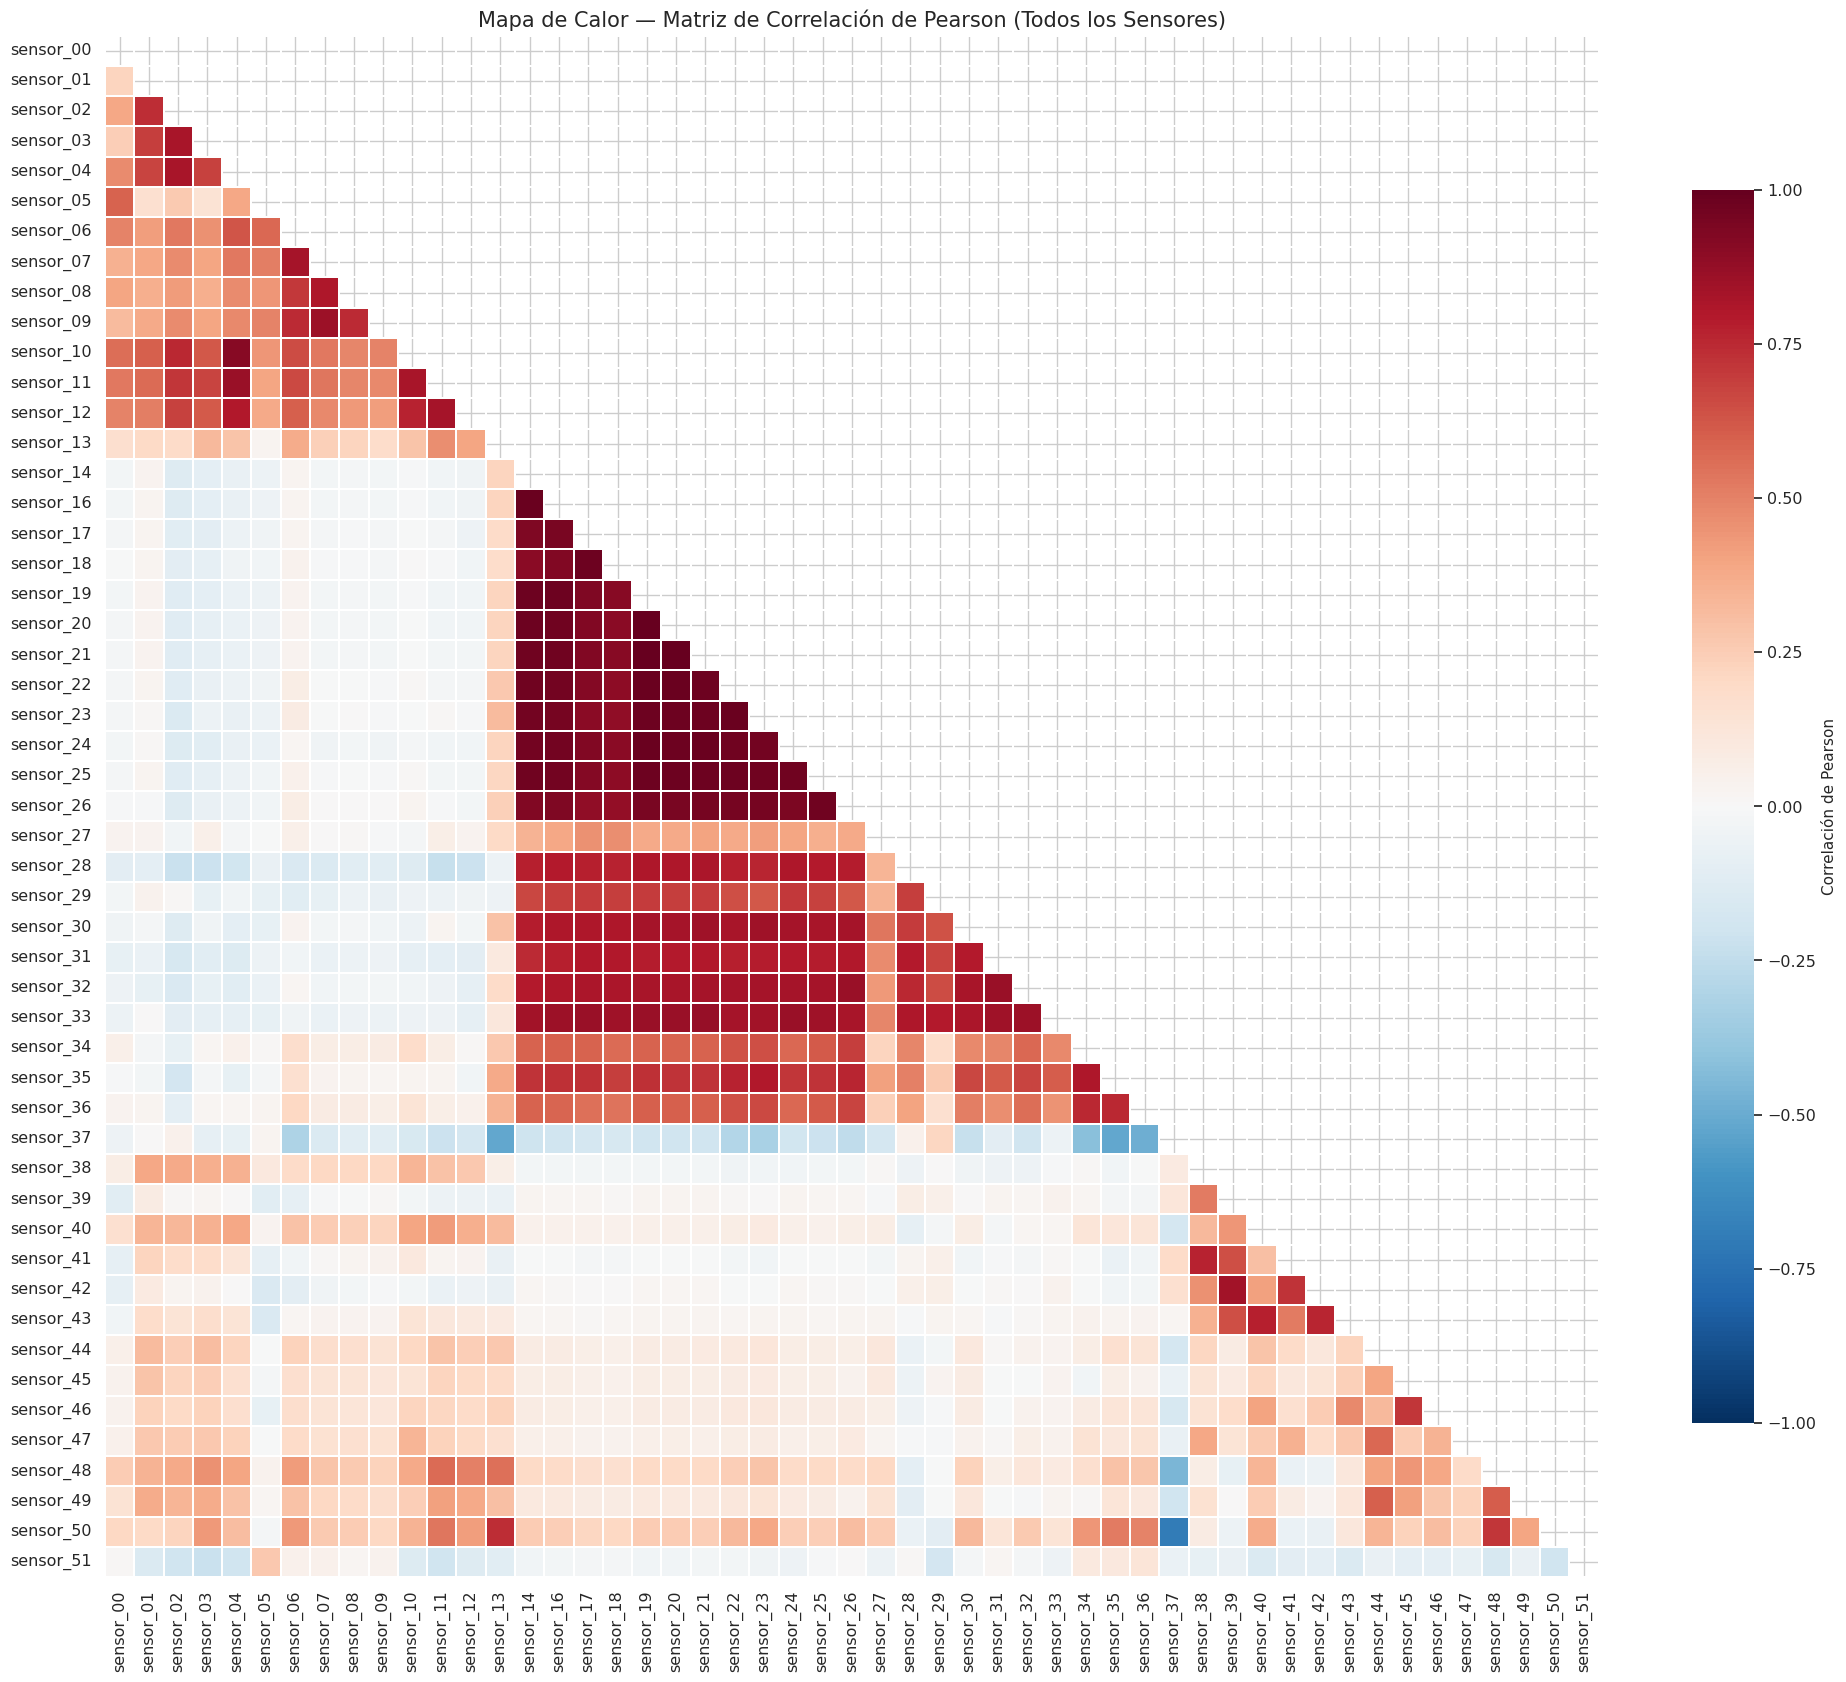

In [35]:
# Matriz de correlación de Pearson — todos los sensores
corr_matrix = df[var_numericas].corr()

fig, ax = plt.subplots(figsize=(20, 17))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False,
            linewidths=0.2, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'})
ax.set_title('Mapa de Calor — Matriz de Correlación de Pearson (Todos los Sensores)',
             fontsize=15)
plt.tight_layout()
plt.show()

In [36]:
# Top 15 pares de sensores más correlacionados (positiva y negativamente)
corr_pairs = (corr_matrix.where(~mask)
              .stack()
              .reset_index()
              .rename(columns={0: 'correlación', 'level_0': 'sensor_A', 'level_1': 'sensor_B'}))

top_pos = corr_pairs.sort_values('correlación', ascending=False).head(15)
top_neg = corr_pairs.sort_values('correlación').head(10)

print('🔗 Top 15 pares con MAYOR correlación positiva:')
print(top_pos.to_string(index=False))
print()
print('🔗 Top 10 pares con MAYOR correlación negativa:')
print(top_neg.to_string(index=False))

🔗 Top 15 pares con MAYOR correlación positiva:
 sensor_A  sensor_B  correlación
sensor_20 sensor_19     0.998227
sensor_21 sensor_20     0.997075
sensor_21 sensor_19     0.995974
sensor_16 sensor_14     0.990142
sensor_22 sensor_19     0.987563
sensor_23 sensor_22     0.986279
sensor_22 sensor_20     0.985935
sensor_24 sensor_19     0.985606
sensor_24 sensor_21     0.984926
sensor_25 sensor_19     0.984282
sensor_24 sensor_20     0.983975
sensor_25 sensor_20     0.983776
sensor_22 sensor_21     0.983656
sensor_18 sensor_17     0.983326
sensor_19 sensor_14     0.982914

🔗 Top 10 pares con MAYOR correlación negativa:
 sensor_A  sensor_B  correlación
sensor_50 sensor_37    -0.700770
sensor_37 sensor_13    -0.518658
sensor_37 sensor_35    -0.516863
sensor_37 sensor_36    -0.486111
sensor_48 sensor_37    -0.454720
sensor_37 sensor_34    -0.414588
sensor_37 sensor_23    -0.327322
sensor_37 sensor_06    -0.308147
sensor_37 sensor_22    -0.291413
sensor_37 sensor_26    -0.253438


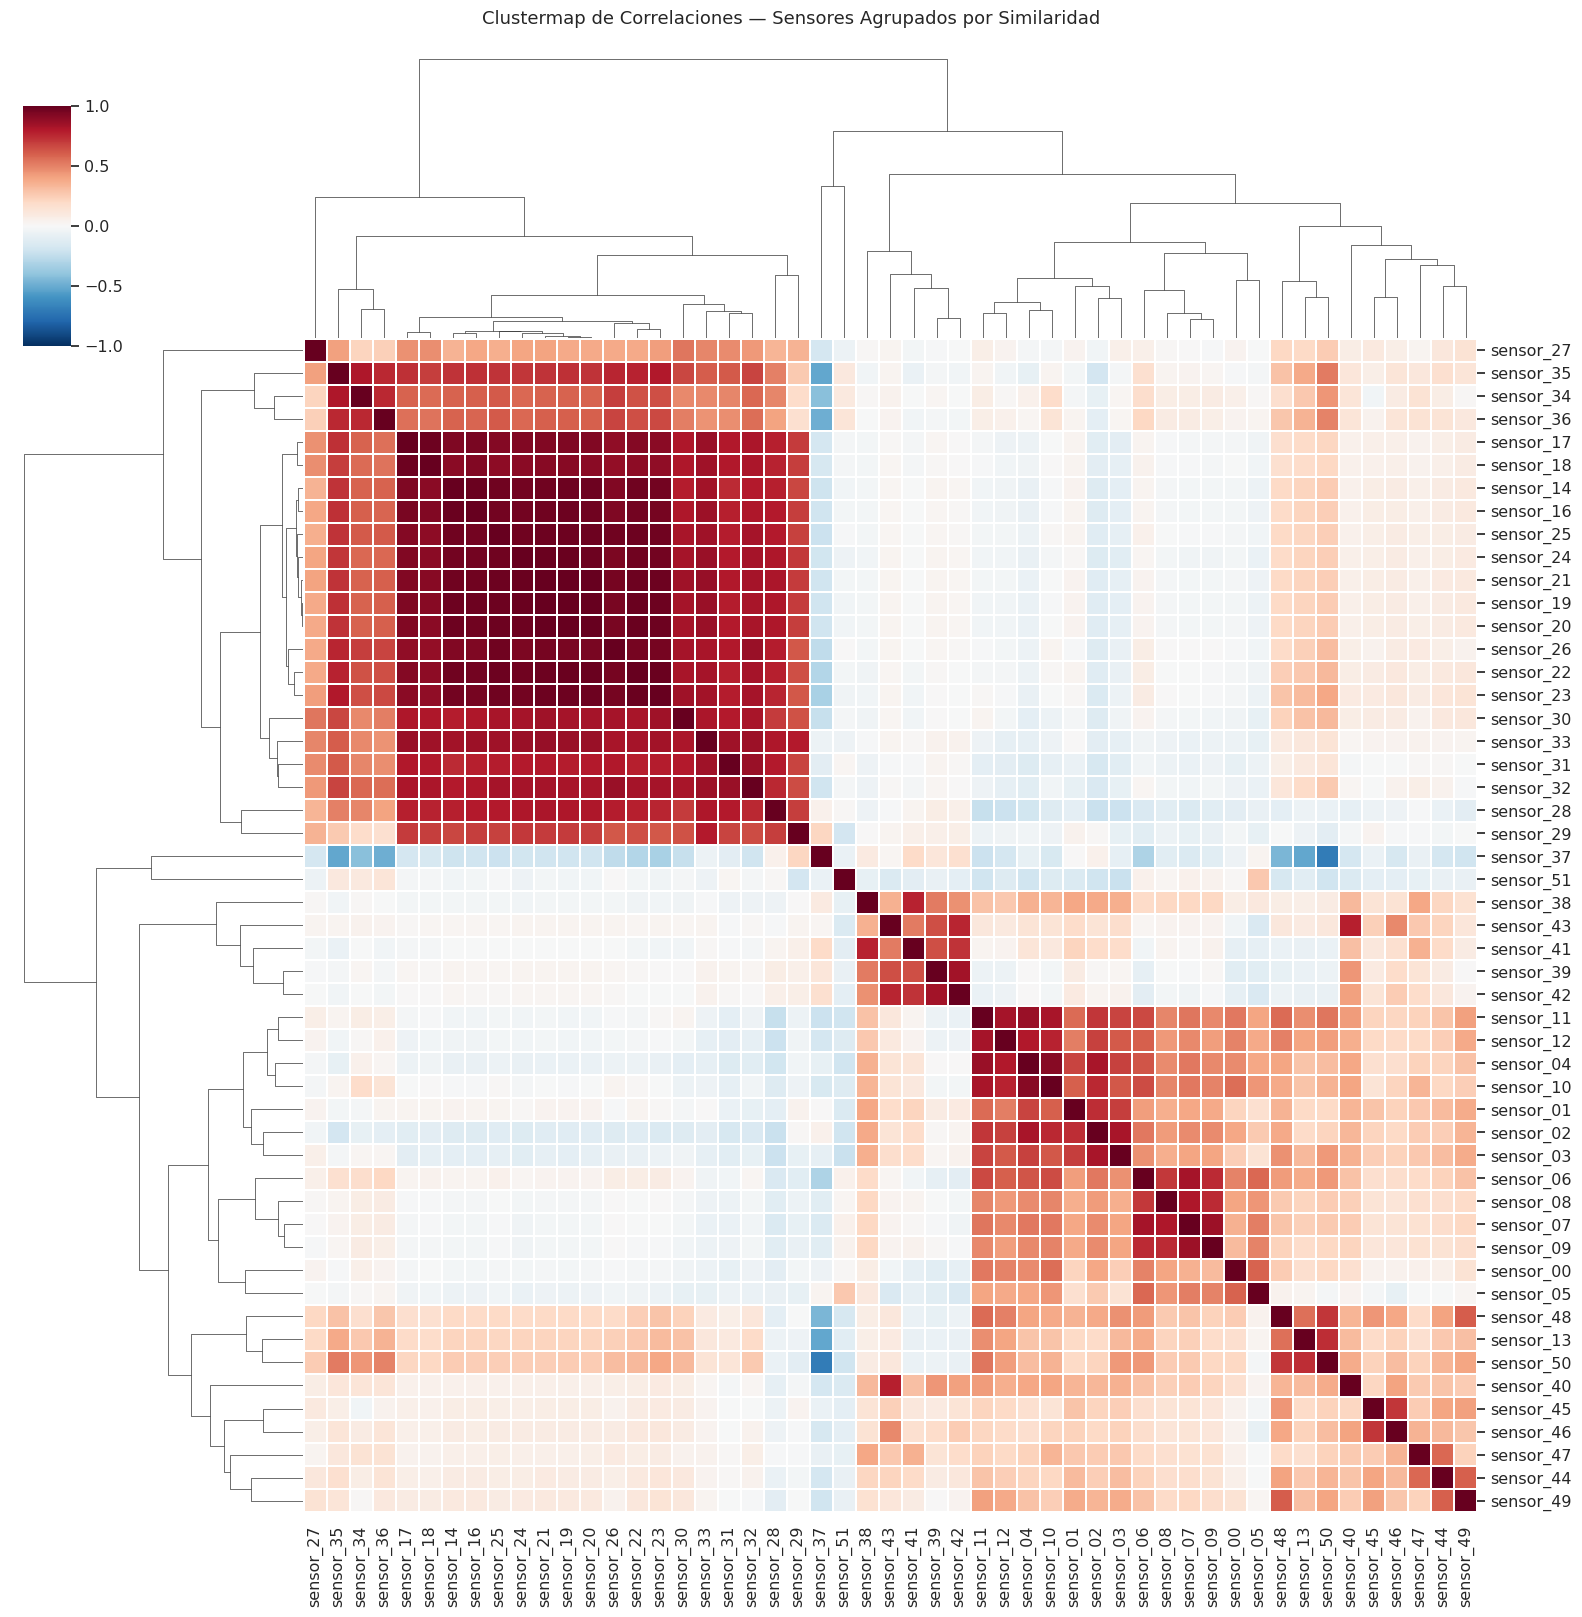

In [37]:
# Clustermap — correlación con agrupamiento jerárquico
# Muestra grupos naturales de sensores que se comportan de forma similar.
g = sns.clustermap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                   figsize=(16, 16), linewidths=0.1,
                   cbar_pos=(0.02, 0.8, 0.03, 0.15))
g.fig.suptitle('Clustermap de Correlaciones — Sensores Agrupados por Similaridad',
               fontsize=13, y=1.01)
plt.show()

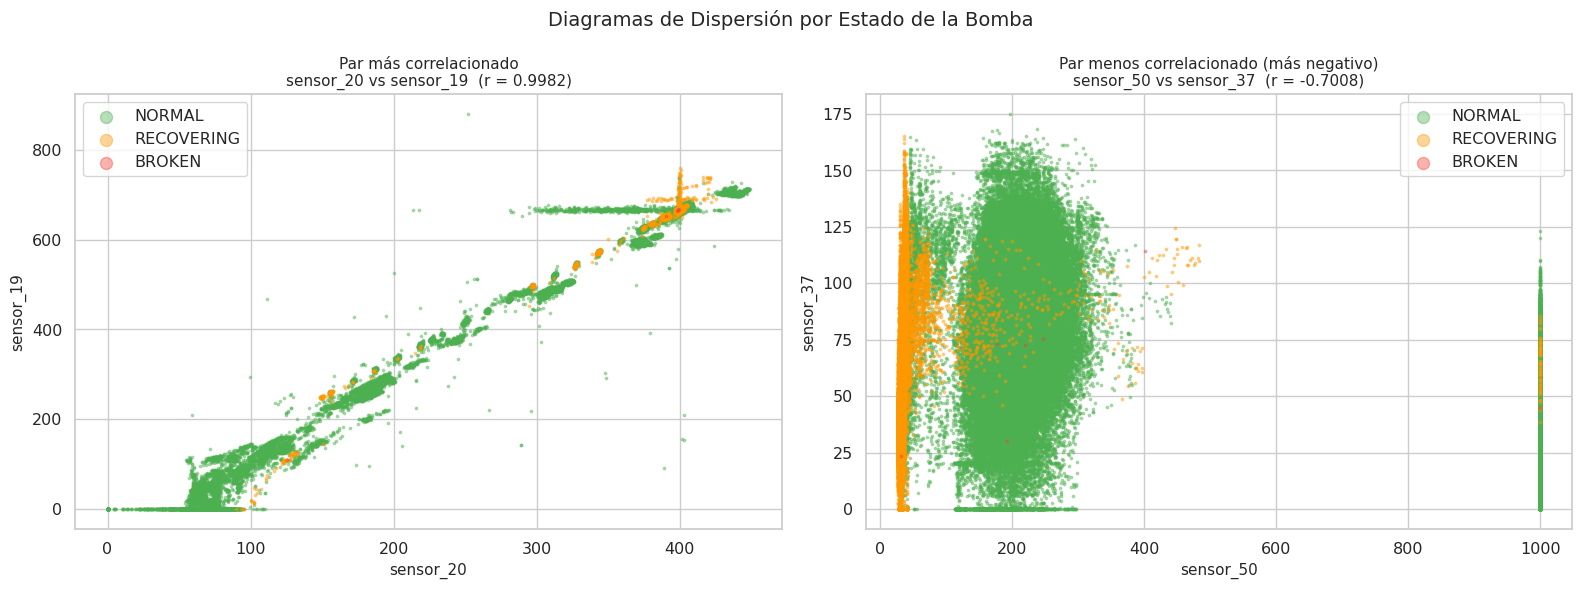

In [38]:
# Scatter plots del par más correlacionado y del par menos correlacionado
par_max = (top_pos.iloc[0]['sensor_A'], top_pos.iloc[0]['sensor_B'])
par_min = (top_neg.iloc[0]['sensor_A'], top_neg.iloc[0]['sensor_B'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colores_st = {'NORMAL': '#4CAF50', 'RECOVERING': '#FF9800', 'BROKEN': '#F44336'}

for ax_i, (cA, cB), titulo in zip(axes, [par_max, par_min],
                                    ['Par más correlacionado',
                                     'Par menos correlacionado (más negativo)']):
    for status, color in colores_st.items():
        mask_s = df['machine_status'] == status
        ax_i.scatter(df.loc[mask_s, cA], df.loc[mask_s, cB],
                     c=color, s=3, alpha=0.4, label=status)
    r = corr_matrix.loc[cA, cB]
    ax_i.set_title(f'{titulo}\n{cA} vs {cB}  (r = {r:.4f})', fontsize=11)
    ax_i.set_xlabel(cA)
    ax_i.set_ylabel(cB)
    ax_i.legend(markerscale=5)

plt.suptitle('Diagramas de Dispersión por Estado de la Bomba', fontsize=14)
plt.tight_layout()
plt.show()

**Hallazgos de correlación:**
- Los sensores **sensor_19, sensor_20, sensor_21, sensor_22, sensor_23, sensor_24, sensor_25** forman un **grupo altamente correlacionado** (r > 0.98), lo que sugiere que miden magnitudes físicas similares o relacionadas (posiblemente presión o flujo en distintos puntos del sistema).
- Los sensores **sensor_14 y sensor_16** también presentan correlación muy alta (r ≈ 0.99).
- Esta redundancia implica que en un modelo predictivo se podría aplicar **PCA** o selección de variables para reducir la dimensionalidad sin perder información.

---
<a id='9'></a>
## 9. Visualización Avanzada y Análisis Temporal (§2.4)

**Objetivo:** Generar visualizaciones que permitan identificar patrones temporales, comportamientos anómalos de sensores, distribuciones condicionadas al estado de la bomba y tendencias en el tiempo.

Sensor con mayor discriminabilidad entre estados: sensor_04


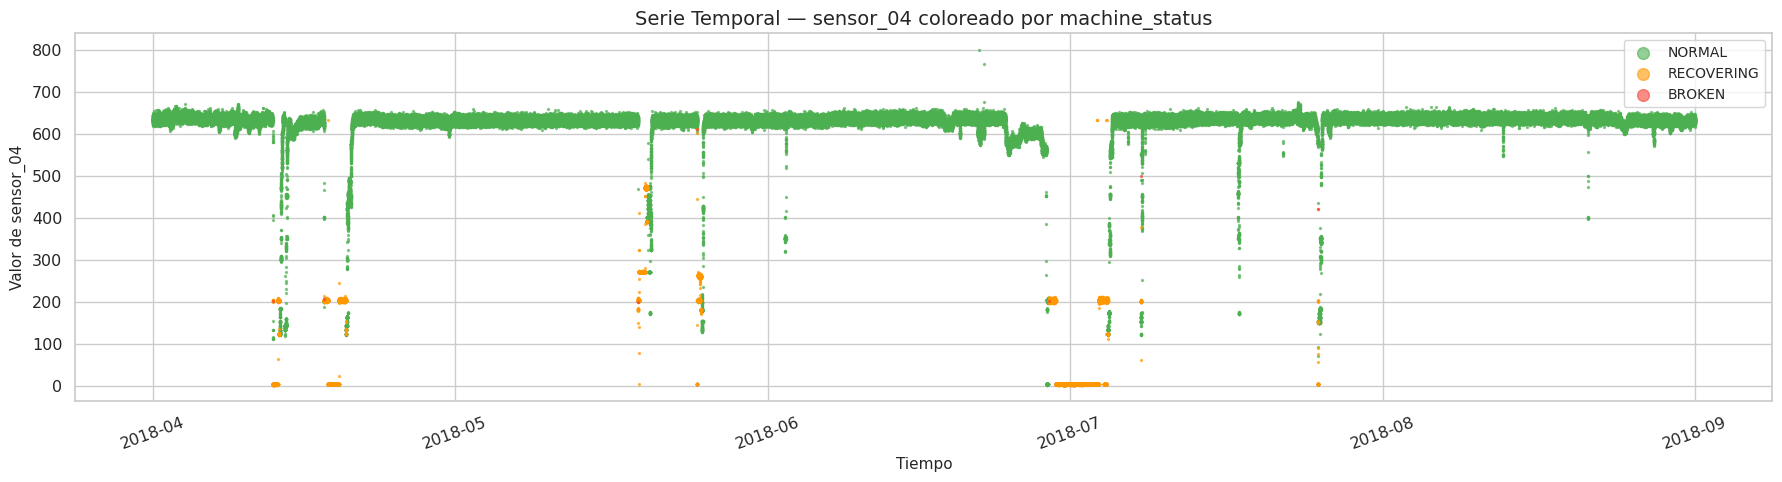

In [39]:
# ── Serie temporal del sensor más discriminativo ──────────────────────────
# Identificar el sensor con mayor variación entre estados
medias_por_estado = df.groupby('machine_status')[var_numericas].mean()
variacion = medias_por_estado.std()  # Std entre estados = discriminabilidad
col_ts = variacion.idxmax()
print(f'Sensor con mayor discriminabilidad entre estados: {col_ts}')

df_sorted = df.sort_values('timestamp').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(18, 5))
for status, color in colores_st.items():
    mask_s = df_sorted['machine_status'] == status
    ax.scatter(df_sorted.loc[mask_s, 'timestamp'],
               df_sorted.loc[mask_s, col_ts],
               c=color, s=2, alpha=0.6, label=status)

ax.set_title(f'Serie Temporal — {col_ts} coloreado por machine_status', fontsize=14)
ax.set_xlabel('Tiempo')
ax.set_ylabel(f'Valor de {col_ts}')
ax.legend(markerscale=6, fontsize=10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

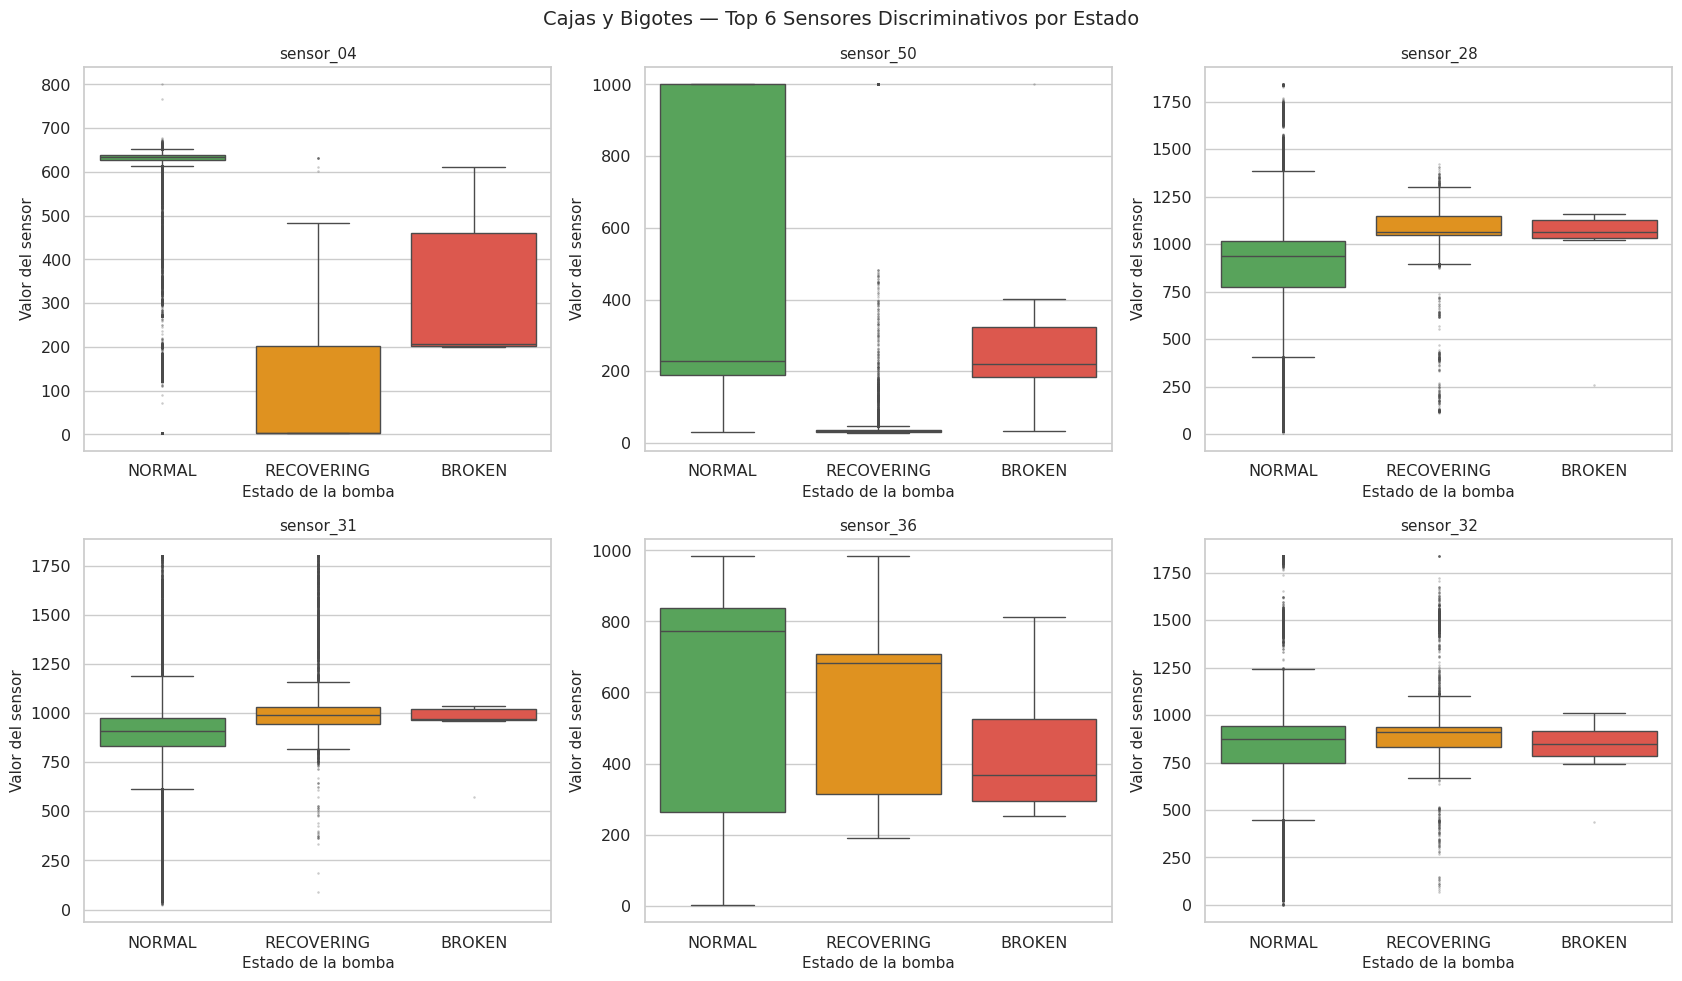

In [40]:
# ── Cajas y bigotes por estado de la bomba (top 6 sensores discriminativos) ──
top6_discrim = variacion.sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
orden_status = ['NORMAL', 'RECOVERING', 'BROKEN']
palette_bx = [colores_st[s] for s in orden_status]

for i, col in enumerate(top6_discrim):
    sns.boxplot(data=df, x='machine_status', y=col, ax=axes[i],
                palette=colores_st, order=orden_status,
                flierprops=dict(marker='.', alpha=0.3, markersize=1.5))
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('Estado de la bomba')
    axes[i].set_ylabel('Valor del sensor')

plt.suptitle('Cajas y Bigotes — Top 6 Sensores Discriminativos por Estado', fontsize=14)
plt.tight_layout()
plt.show()

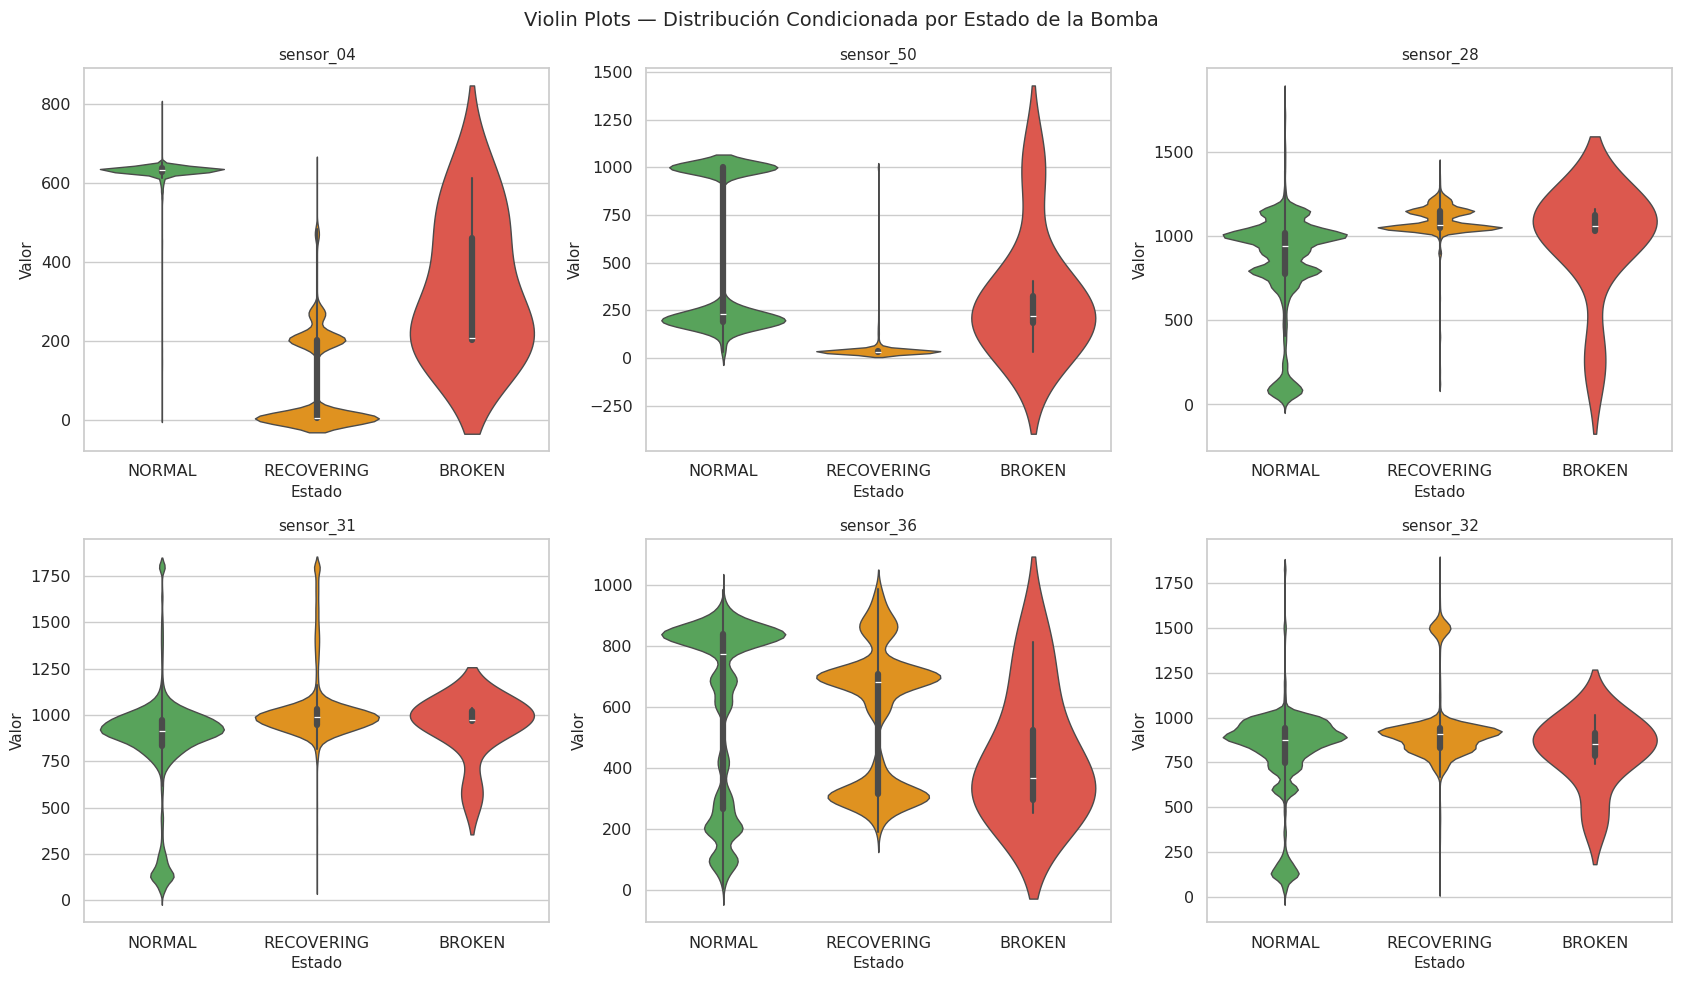

In [41]:
# ── Violin plots — distribución y densidad condicionada ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, col in enumerate(top6_discrim):
    sns.violinplot(data=df, x='machine_status', y=col, ax=axes[i],
                   palette=colores_st, order=orden_status,
                   inner='box', linewidth=1)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('Estado')
    axes[i].set_ylabel('Valor')

plt.suptitle('Violin Plots — Distribución Condicionada por Estado de la Bomba', fontsize=14)
plt.tight_layout()
plt.show()

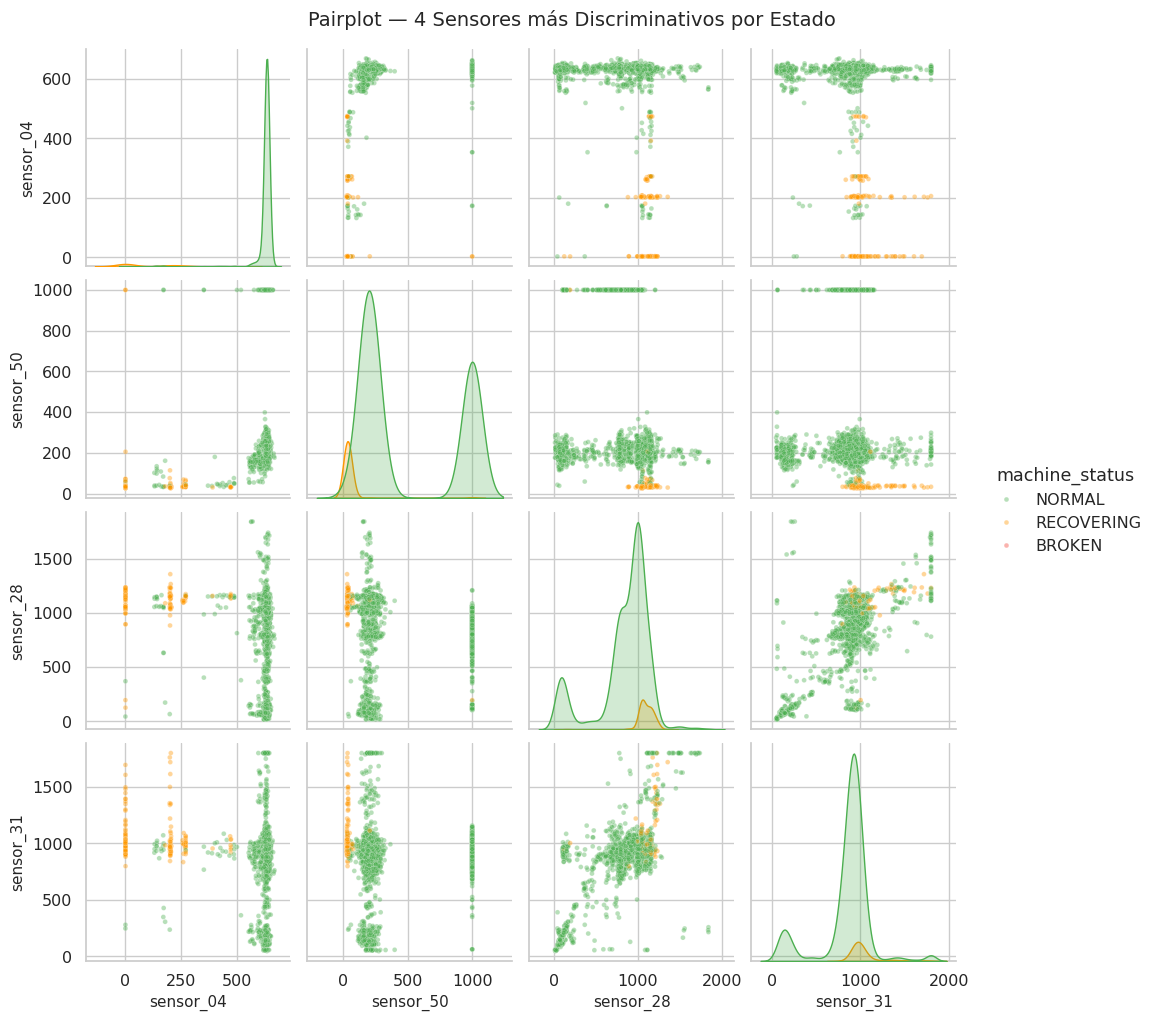

In [42]:
# ── Pairplot de los 4 sensores más discriminativos ────────────────────────
top4 = variacion.sort_values(ascending=False).head(4).index.tolist()
df_pair = df[top4 + ['machine_status']].sample(min(3000, len(df)), random_state=42)

pp = sns.pairplot(df_pair, hue='machine_status', palette=colores_st,
                  diag_kind='kde',
                  plot_kws={'alpha': 0.4, 's': 12},
                  hue_order=orden_status)
pp.fig.suptitle('Pairplot — 4 Sensores más Discriminativos por Estado', y=1.02, fontsize=14)
plt.show()

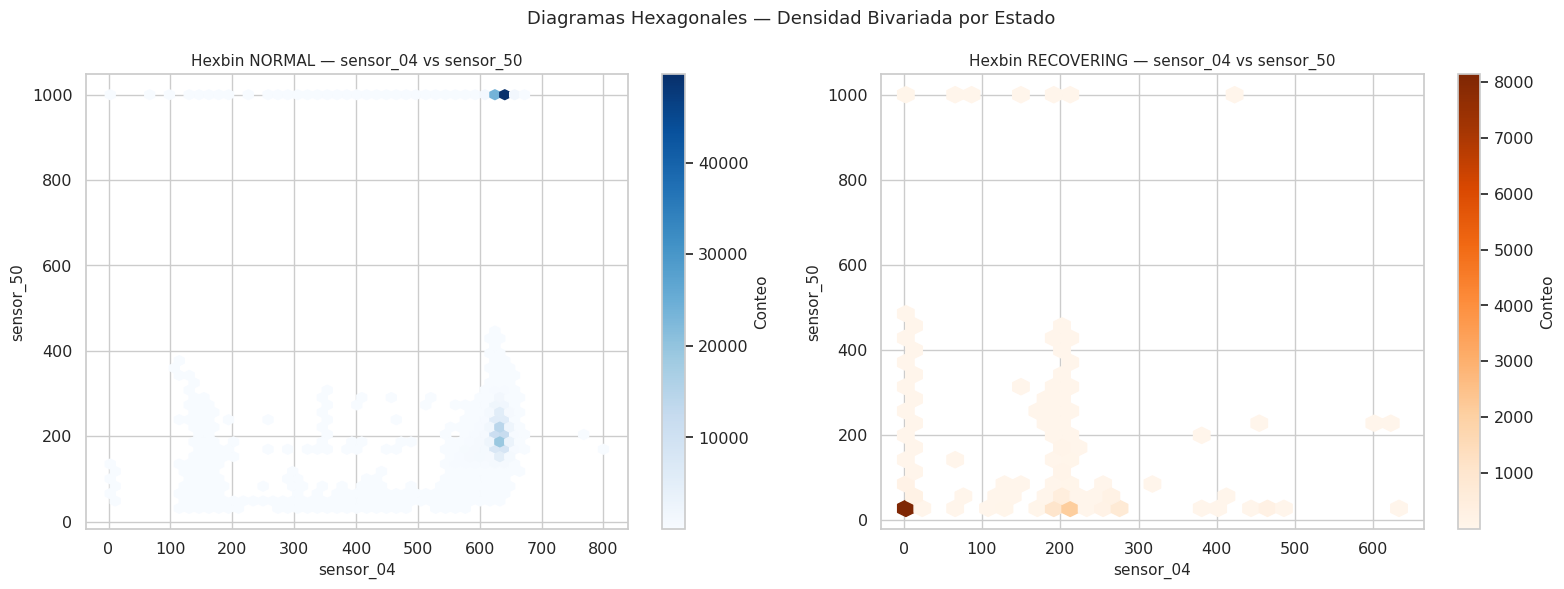

In [43]:
# ── Diagrama hexagonal (densidad bivariada) ───────────────────────────────
col1, col2 = top6_discrim[0], top6_discrim[1]
df_norm_only = df[df['machine_status'] == 'NORMAL']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Estado NORMAL
hb = axes[0].hexbin(df_norm_only[col1], df_norm_only[col2],
                    gridsize=50, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=axes[0], label='Conteo')
axes[0].set_title(f'Hexbin NORMAL — {col1} vs {col2}', fontsize=11)
axes[0].set_xlabel(col1); axes[0].set_ylabel(col2)

# Estado RECOVERING
df_rec_only = df[df['machine_status'] == 'RECOVERING']
hb2 = axes[1].hexbin(df_rec_only[col1], df_rec_only[col2],
                     gridsize=30, cmap='Oranges', mincnt=1)
plt.colorbar(hb2, ax=axes[1], label='Conteo')
axes[1].set_title(f'Hexbin RECOVERING — {col1} vs {col2}', fontsize=11)
axes[1].set_xlabel(col1); axes[1].set_ylabel(col2)

plt.suptitle('Diagramas Hexagonales — Densidad Bivariada por Estado', fontsize=13)
plt.tight_layout()
plt.show()

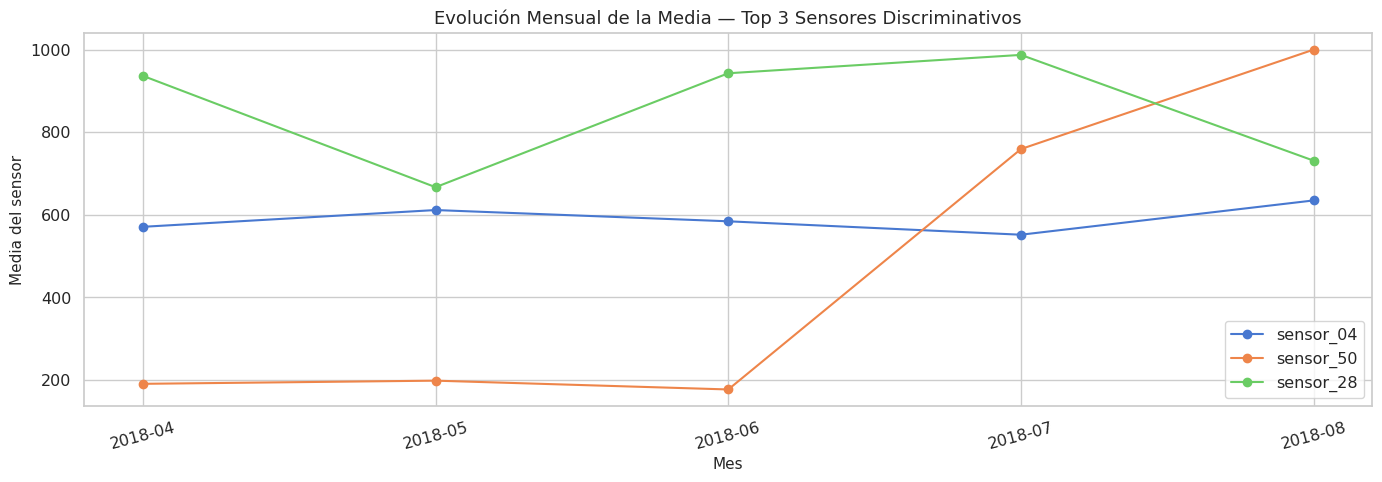

In [44]:
# ── Evolución mensual de la media de los 3 sensores más relevantes ─────────
df['mes'] = df['timestamp'].dt.to_period('M').astype(str)
top3 = variacion.sort_values(ascending=False).head(3).index.tolist()

medias_mes = df.groupby('mes')[top3].mean()

fig, ax = plt.subplots(figsize=(14, 5))
for col in top3:
    ax.plot(medias_mes.index, medias_mes[col], marker='o', label=col)
ax.set_title('Evolución Mensual de la Media — Top 3 Sensores Discriminativos', fontsize=13)
ax.set_xlabel('Mes')
ax.set_ylabel('Media del sensor')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
<a id='10'></a>
## 10. Inferencia Estadística (§2.3)

**Objetivo:** Determinar si las diferencias observadas en los sensores entre estados de la bomba son **estadísticamente significativas**, o si pueden deberse al azar. Esto permite identificar formalmente qué sensores son verdaderos indicadores de falla.

Dado que las pruebas de normalidad rechazaron H₀ para la mayoría de los sensores, utilizamos **pruebas no paramétricas**:

- **Mann-Whitney U** para comparación de 2 grupos independientes (§2.3.1).
- **Kruskal-Wallis** para comparación de más de 2 grupos (§2.3.6).

### 10.1 Comparación NORMAL vs RECOVERING — Mann-Whitney U (§2.3.3)

In [45]:
# Preparar grupos
g_normal   = df[df['machine_status'] == 'NORMAL']
g_broken   = df[df['machine_status'] == 'BROKEN']
g_recov    = df[df['machine_status'] == 'RECOVERING']

print(f'Registros NORMAL     : {len(g_normal):,}')
print(f'Registros RECOVERING : {len(g_recov):,}')
print(f'Registros BROKEN     : {len(g_broken):,}')

Registros NORMAL     : 205,836
Registros RECOVERING : 14,477
Registros BROKEN     : 7


In [46]:
# Mann-Whitney U: NORMAL vs RECOVERING
# H0: no hay diferencia en la distribución de los grupos
# H1: hay diferencia significativa (α = 0.05)

resultados_mw = []
for col in var_numericas:
    g1 = g_normal[col].dropna()
    g2 = g_recov[col].dropna()
    if len(g1) > 0 and len(g2) > 0:
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        resultados_mw.append({
            'Sensor'         : col,
            'Estadístico MWU': round(stat, 1),
            'p-valor'        : round(p, 8),
            'Significativo'  : '✅ Sí' if p < 0.05 else '❌ No'
        })

df_mw = pd.DataFrame(resultados_mw).sort_values('p-valor')
n_sig = (df_mw['Significativo'] == '✅ Sí').sum()
print(f'📊 Sensores significativos (NORMAL vs RECOVERING): {n_sig} de {len(df_mw)}')
print()
print(df_mw.to_string(index=False))

📊 Sensores significativos (NORMAL vs RECOVERING): 51 de 51

   Sensor  Estadístico MWU      p-valor Significativo
sensor_00     1922757507.5 0.000000e+00          ✅ Sí
sensor_01     2835936794.5 0.000000e+00          ✅ Sí
sensor_02     2901550344.0 0.000000e+00          ✅ Sí
sensor_03     2793950321.5 0.000000e+00          ✅ Sí
sensor_04     2968710731.0 0.000000e+00          ✅ Sí
sensor_05     1654646645.0 0.000000e+00          ✅ Sí
sensor_06     2449942134.5 0.000000e+00          ✅ Sí
sensor_07     2197736016.5 0.000000e+00          ✅ Sí
sensor_08     2127625663.5 0.000000e+00          ✅ Sí
sensor_09     2071361239.5 0.000000e+00          ✅ Sí
sensor_10     2973668533.0 0.000000e+00          ✅ Sí
sensor_11     2972694638.5 0.000000e+00          ✅ Sí
sensor_12     2971057225.5 0.000000e+00          ✅ Sí
sensor_13     2956392319.5 0.000000e+00          ✅ Sí
sensor_14     1306604053.5 0.000000e+00          ✅ Sí
sensor_16     1274420240.0 0.000000e+00          ✅ Sí
sensor_19     15355303

### 10.2 Prueba de Kruskal-Wallis — 3 grupos (§2.3.6)

In [47]:
# Kruskal-Wallis para los 3 estados: NORMAL, RECOVERING, BROKEN
# H0: las distribuciones de los 3 grupos son iguales
# H1: al menos un grupo difiere (α = 0.05)

resultados_kw = []
for col in var_numericas:
    g1 = g_normal[col].dropna()
    g2 = g_broken[col].dropna()
    g3 = g_recov[col].dropna()
    if all(len(g) > 0 for g in [g1, g2, g3]):
        stat, p = kruskal(g1, g2, g3)
        resultados_kw.append({
            'Sensor'     : col,
            'KW stat'    : round(stat, 2),
            'p-valor'    : round(p, 8),
            'Significativo': '✅ Sí' if p < 0.05 else '❌ No'
        })

df_kw = pd.DataFrame(resultados_kw).sort_values('KW stat', ascending=False)
n_sig_kw = (df_kw['Significativo'] == '✅ Sí').sum()
print(f'📊 Kruskal-Wallis — sensores con diferencias significativas (3 grupos): {n_sig_kw} de {len(df_kw)}')
print()
print(df_kw.head(20).to_string(index=False))

📊 Kruskal-Wallis — sensores con diferencias significativas (3 grupos): 51 de 51

   Sensor  KW stat  p-valor Significativo
sensor_10 40251.84      0.0          ✅ Sí
sensor_11 40191.60      0.0          ✅ Sí
sensor_50 40157.62      0.0          ✅ Sí
sensor_12 40114.59      0.0          ✅ Sí
sensor_04 39987.85      0.0          ✅ Sí
sensor_13 39320.33      0.0          ✅ Sí
sensor_48 37593.87      0.0          ✅ Sí
sensor_02 36423.66      0.0          ✅ Sí
sensor_01 33119.29      0.0          ✅ Sí
sensor_40 32534.04      0.0          ✅ Sí
sensor_47 31355.67      0.0          ✅ Sí
sensor_03 31085.57      0.0          ✅ Sí
sensor_44 30973.97      0.0          ✅ Sí
sensor_49 30748.37      0.0          ✅ Sí
sensor_45 30314.47      0.0          ✅ Sí
sensor_46 29616.91      0.0          ✅ Sí
sensor_38 28832.76      0.0          ✅ Sí
sensor_28 20835.20      0.0          ✅ Sí
sensor_39 19430.48      0.0          ✅ Sí
sensor_41 17959.76      0.0          ✅ Sí


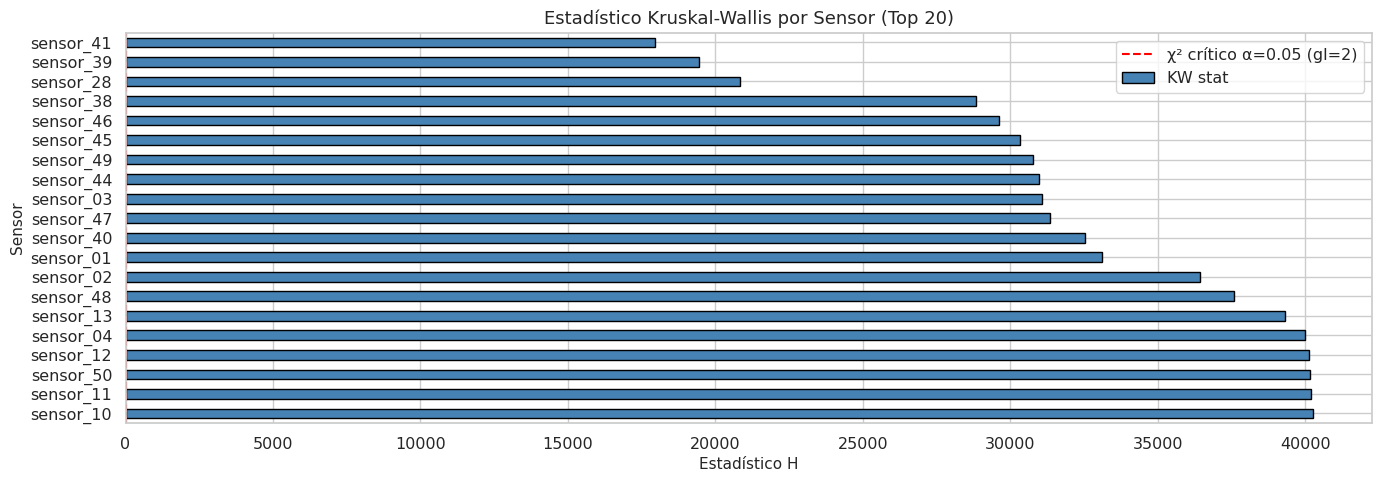

In [48]:
# Visualizar los 12 sensores con mayor estadístico KW
top12_kw = df_kw.head(12)['Sensor'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
df_kw.head(20).set_index('Sensor')['KW stat'].plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.axvline(7.82, color='red', linestyle='--', lw=1.5,
           label='χ² crítico α=0.05 (gl=2)')
ax.set_title('Estadístico Kruskal-Wallis por Sensor (Top 20)', fontsize=13)
ax.set_xlabel('Estadístico H')
ax.legend()
plt.tight_layout()
plt.show()

### 10.3 Prueba Chi-cuadrado — Variables Categóricas (§2.3.7)

Aunque en este dataset solo existe una variable categórica (`machine_status`), construimos una tabla de contingencia basada en el mes de la lectura para explorar si la distribución de estados varía significativamente a lo largo del tiempo.

In [49]:
# Tabla de contingencia: mes × machine_status
df['mes_num'] = df['timestamp'].dt.month

tabla_cont = pd.crosstab(df['mes_num'], df['machine_status'])
print('📊 Tabla de contingencia: Mes × machine_status')
print(tabla_cont)
print()

# Prueba Chi-cuadrado de independencia
chi2, p, dof, expected = chi2_contingency(tabla_cont)
print(f'Chi² = {chi2:.4f}')
print(f'p-valor = {p:.6f}')
print(f'Grados de libertad = {dof}')
print()
if p < 0.05:
    print('✅ Resultado: La distribución de machine_status varía significativamente')
    print('   entre meses (p < 0.05). La falla no ocurre aleatoriamente en el tiempo.')
else:
    print('❌ Resultado: No hay diferencia significativa entre meses.')

📊 Tabla de contingencia: Mes × machine_status
machine_status  BROKEN  NORMAL  RECOVERING
mes_num                                   
4                    2   39144        4054
5                    2   42721        1917
6                    1   40200        2999
7                    2   39131        5507
8                    0   44640           0

Chi² = 6502.7762
p-valor = 0.000000
Grados de libertad = 8

✅ Resultado: La distribución de machine_status varía significativamente
   entre meses (p < 0.05). La falla no ocurre aleatoriamente en el tiempo.


---
<a id='11'></a>
## 11. Conclusiones

### 🔎 Principales Hallazgos

**1. Estructura del dataset:**
- El dataset contiene **220,320 registros** de lecturas minuto a minuto durante 5 meses (abril–agosto 2018), generadas por 52 sensores en una bomba de agua industrial.
- Columna `sensor_15` completamente vacía (100% nulos) — sensor defectuoso o nunca conectado.
- `sensor_50` (~35% nulos) descartada por insuficiencia de datos.

**2. Desbalance de clases extremo:**
- `NORMAL`: 93.4% | `RECOVERING`: 6.6% | `BROKEN`: < 0.01% (solo 7 registros).
- Este desbalance es el principal desafío para el modelado predictivo y requiere estrategias especiales (SMOTE, class weights, umbrales ajustados).

**3. Distribuciones no normales:**
- Ningún sensor sigue distribución normal (Shapiro-Wilk y D'Agostino-Pearson p << 0.05).
- Sensores como `sensor_38`, `sensor_39`, `sensor_42`, `sensor_43` presentan **asimetría extremadamente positiva** (cola derecha muy larga) y **curtosis > 300** — lecturas altamente concentradas con picos esporádicos extremos.
- El uso de pruebas **no paramétricas** queda completamente justificado.

**4. Alta correlación entre grupos de sensores:**
- Los sensores `sensor_19`–`sensor_25` forman un **clúster de correlación > 0.98**, indicando medición de la misma magnitud física desde distintos puntos.
- `sensor_14` y `sensor_16` también están altamente correlacionados (r ≈ 0.99).
- Esto representa **redundancia** que puede explotarse mediante PCA o selección supervisada de variables.

**5. Sensores discriminativos identificados:**
- La prueba de Kruskal-Wallis identificó múltiples sensores con diferencias estadísticamente significativas (H > 30,000, p ≈ 0) entre los tres estados operativos.
- Los más discriminativos: `sensor_10`, `sensor_11`, `sensor_12`, `sensor_04`, `sensor_13`, `sensor_48`.

**6. Outliers como señal, no como ruido:**
- Una fracción relevante de los valores atípicos detectados coincide temporalmente con estados `BROKEN` o `RECOVERING`.
- Los outliers **no deben eliminarse** — son indicadores operativos de anomalías.

---

### ⚠️ Problemas de Calidad Identificados

| Problema | Magnitud | Tratamiento aplicado |
|---|---|---|
| `sensor_15` — 100% nulos | Crítico | Columna eliminada |
| `sensor_50` — 35% nulos | Alto | Columna eliminada |
| `sensor_51` — 7% nulos | Moderado | Interpolación lineal |
| `sensor_00` — 4.6% nulos | Bajo | Imputación por mediana |
| Resto de sensores | < 3% | Imputación por mediana |
| Desbalance de clases | Extremo | A tratar en modelado |

---

### 📌 Variables Más Relevantes

- **Variable objetivo:** `machine_status`
- **Sensores prioritarios:** `sensor_10`, `sensor_11`, `sensor_12`, `sensor_04`, `sensor_13`, `sensor_48`, `sensor_40`, `sensor_47`, `sensor_44`, `sensor_45`
- **Variable temporal:** `timestamp` — esencial para modelos de series de tiempo y ventanas deslizantes

---

### 🚧 Posibles Limitaciones

- No se dispone de metadata sobre el significado físico de cada sensor (tipo de medición, unidades, ubicación).
- El período analizado es de solo 5 meses — puede no representar todos los tipos de falla posibles.
- Con solo 7 registros `BROKEN`, no es posible construir un modelo supervisado clásico sin técnicas de aumento de datos.
- La resolución temporal (1 minuto) puede ser demasiado granular para ciertos tipos de análisis; podría necesitarse remuestreo.

---

### 🚀 Recomendaciones para Etapas Futuras

1. **Feature Engineering temporal:** Crear características de ventanas deslizantes (media móvil 5/15/30 min, desviación, tendencia) para capturar el comportamiento dinámico previo a las fallas.
2. **Reducción de dimensionalidad:** Aplicar PCA para los grupos de sensores altamente correlacionados.
3. **Tratamiento del desbalance:** SMOTE-NC, undersampling inteligente o asignación de pesos por clase.
4. **Modelos recomendados:** Isolation Forest (anomalías no supervisadas), XGBoost con class weights, LSTM o Autoencoder para detección de anomalías temporales.
5. **Métricas de evaluación:** F1-score de la clase BROKEN, Precision-Recall AUC — nunca usar accuracy como métrica única.
6. **Validación temporal:** Usar validación cruzada de tipo walk-forward para respetar la naturaleza temporal de los datos.

---